In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [68]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

In [69]:
data

,Date,User Count Average,Average User Throughput DL,Average User Throughput UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,Data Volume DL,User Count Maximum,S1_SIG_SUCC,TOTAL_DOWNTIME,Traffic,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
0,1-Apr-23,23286.87,5.633309,0.679596,98.804118,0.988493,12.778676,0.317022,34.709118,43047497.21,46889,251417.5882,149.154412,49209296.38,43.460147,6161799.12
1,1-Aug-23,23677.76,7.364028,0.471457,95.325628,0.820870,7.653198,0.066296,35.626903,50313422.69,59988,122458.1053,3983.046559,56692531.22,40.117105,6379108.66
2,1-Dec-22,20755.21,5.066298,0.644504,97.453779,0.917099,10.162252,0.093053,34.349733,38831073.14,41009,244848.5649,2167.549618,44311619.79,35.898473,5480546.64
3,1-Feb-23,21880.87,5.382316,0.792096,98.227500,1.016471,12.823051,0.202574,35.099449,39888353.28,43346,241229.6471,22.955882,45724214.07,42.006801,5835860.74
4,1-Jan-23,20811.78,5.389850,0.704850,98.747444,0.939248,10.303647,0.164361,36.835038,36907578.16,40927,241561.7820,0.000000,42734990.38,37.557368,5827412.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,9-Mar-23,23350.58,5.057684,0.742757,98.266507,1.002463,12.961728,0.197096,35.234963,41676401.56,45812,249644.5074,6.106618,47851202.93,41.218088,6174801.32
362,9-May-23,22459.26,5.047216,0.716923,99.384286,1.012454,9.975018,0.304176,34.966886,42117368.21,45766,249021.0330,447.410256,48156570.69,42.919341,6039202.57
363,9-Nov-22,17475.45,3.133588,0.517557,97.921145,0.927290,11.786832,0.102977,35.045382,29272509.30,39918,218947.5573,1449.561069,33761716.22,38.948511,4489206.83
364,9-Oct-22,16437.81,3.316680,0.559040,98.747840,0.959960,10.710440,0.130640,35.621360,30127950.12,34459,216222.9000,694.732000,34672216.32,37.295080,4544265.80


Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.006067692221627302
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.006067692221627302
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.0013386559474354346
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.0013386559474354346
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.0012729550076118691
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.0012729550076118691
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.0046628240407093095
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.009040197714730563
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.0050662971926372
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.001261591095597958
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.005000963552426449
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.00115260

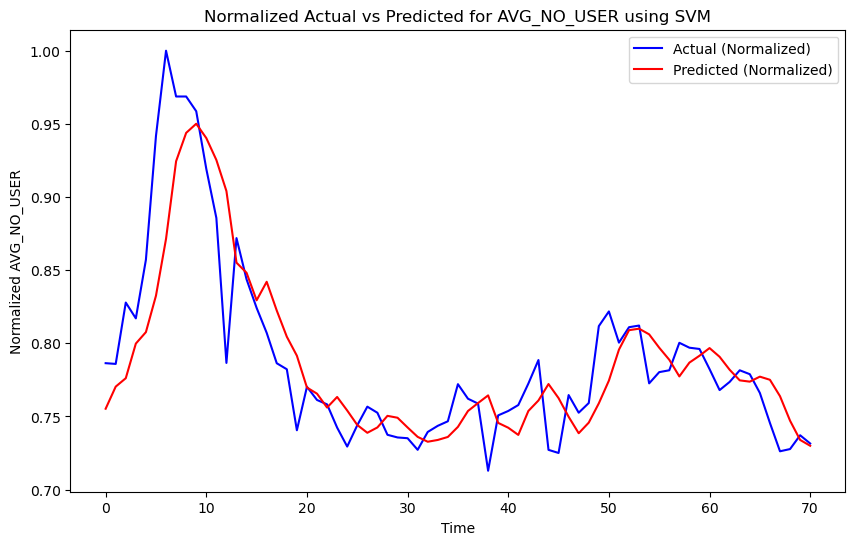

In [67]:


# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'AVG_NO_USER'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

18:58:56 - cmdstanpy - INFO - Chain [1] start processing
18:58:57 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\994309429.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\994309429.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])


Evaluation Metrics:
MSE: 279725.8084236613
MAE: 329.43991728494547
MAPE: 3.334956815087263%
RMSE: 528.8911120671828
R-squared: -0.17862401123276284
MASE: 1.7906196018697433
Forecast Bias: -193.23671762740588


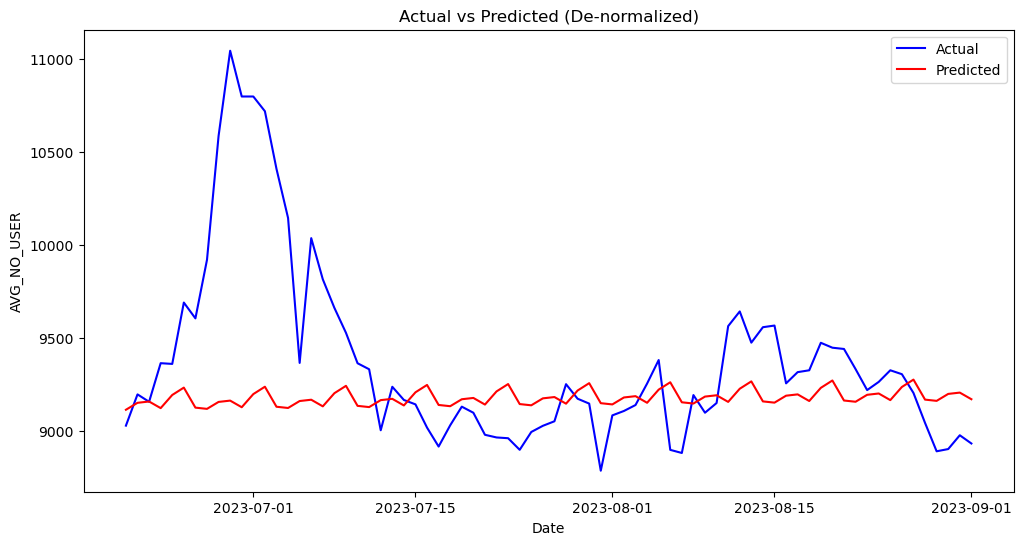

In [52]:

# Custom function to calculate MASE
def calculate_mase(actual, predicted, training_series):
    naive_forecast = training_series[:-1]
    actual_forecast = training_series[1:]
    mae_naive = np.mean(np.abs(actual_forecast - naive_forecast))
    mase = mean_absolute_error(actual, predicted) / mae_naive
    return mase

# Load and prepare data
data_prophet = data[['Date', 'AVG_NO_USER']].rename(columns={'Date': 'ds', 'AVG_NO_USER': 'y'})

# Normalize the data
max_value = data_prophet['y'].max()
data_prophet['y'] /= max_value

# Split the data into training and test sets
train_size = int(len(data_prophet) * 0.8)
train, test = data_prophet.iloc[:train_size], data_prophet.iloc[train_size:]

# Initialize and fit the Prophet model
prophet_model = Prophet()
prophet_model.fit(train)

# Create a future dataframe and forecast
future = prophet_model.make_future_dataframe(periods=len(test), freq='D')
forecast = prophet_model.predict(future)

# Extract the predicted values for the test set
test_predictions = forecast[['ds', 'yhat']].iloc[-len(test):]
test_predictions['yhat'] *= max_value  # De-normalize predictions
test['y'] *= max_value  # De-normalize actual values

# Calculate evaluation metrics
mse = mean_squared_error(test['y'], test_predictions['yhat'])
mae = mean_absolute_error(test['y'], test_predictions['yhat'])
mape = np.mean(np.abs((test['y'] - test_predictions['yhat']) / test['y'])) * 100
rmse = np.sqrt(mse)
r_squared = r2_score(test['y'], test_predictions['yhat'])
mase = calculate_mase(test['y'].values, test_predictions['yhat'].values, train['y'].values * max_value)
forecast_bias = np.mean(test_predictions['yhat'] - test['y'])

# Display evaluation metrics
print("Evaluation Metrics:")
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")
print(f"RMSE: {rmse}")
print(f"R-squared: {r_squared}")
print(f"MASE: {mase}")
print(f"Forecast Bias: {forecast_bias}")

# Ensure the 'ds' column is in datetime format
test['ds'] = pd.to_datetime(test['ds'])
test_predictions['ds'] = pd.to_datetime(test_predictions['ds'])

# Plot the actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(test['ds'], test['y'], label='Actual', color='blue')
plt.plot(test_predictions['ds'], test_predictions['yhat'], label='Predicted', color='red')
plt.title('Actual vs Predicted (De-normalized)')
plt.xlabel('Date')
plt.ylabel('AVG_NO_USER')
plt.legend()
plt.show()

In [57]:
data_prophet

,ds,y
0,2022-09-01 00:00:00,0.626664
1,2022-09-02 00:00:00,0.626411
2,2022-09-03 00:00:00,0.620548
3,2022-09-04 00:00:00,0.620012
4,2022-09-05 00:00:00,0.614432
...,...,...
361,2023-08-28 00:00:00,9044.900000
362,2023-08-29 00:00:00,8892.820000
363,2023-08-30 00:00:00,8904.820000
364,2023-08-31 00:00:00,8978.820000


In [71]:
# Function to calculate MASE
def calculate_mase(actual, predicted, training_series):
    naive_forecast = training_series[:-1]
    actual_forecast = training_series[1:]
    mae_naive = np.mean(np.abs(actual_forecast - naive_forecast))
    mase = mean_absolute_error(actual, predicted) / mae_naive
    return mase

# Load and prepare data
data = pd.read_csv('../../data/Tdata.csv')
# Select target column 'y' and regressors
data = data[['ds', 'y', 'AVG_NO_USER', 'DL_TRAFFIC_MB', 'UL_TRAFFIC_MB']]  # Include all relevant columns


In [77]:
# Load and prepare data
df = pd.read_csv('../../data/Tdata.csv')
# Select target column 'y' and regressors
data = df[['ds', 'y', 'AVG_NO_USER', 'DL_TRAFFIC_MB', 'UL_TRAFFIC_MB']]  # Include all relevant columns


KeyError: "['ds', 'y', 'AVG_NO_USER', 'DL_TRAFFIC_MB'] not in index"

In [74]:
data

,ds,y
0,1-Apr-23,49209296.38
1,1-Aug-23,56692531.22
2,1-Dec-22,44311619.79
3,1-Feb-23,45724214.07
4,1-Jan-23,42734990.38
...,...,...
361,9-Mar-23,47851202.93
362,9-May-23,48156570.69
363,9-Nov-22,33761716.22
364,9-Oct-22,34672216.32


C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:16:53 - cmdstanpy - INFO - Chain [1] start processing


Processing column: Average User Throughput DL


19:16:53 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


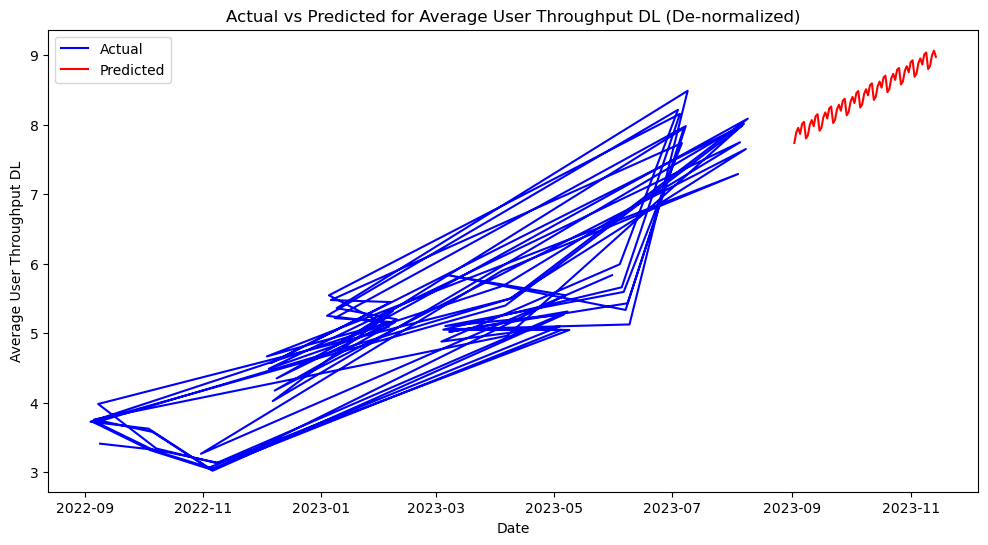

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:16:54 - cmdstanpy - INFO - Chain [1] start processing
19:16:54 - cmdstanpy - INFO - Chain [1] done processing


Metrics for Average User Throughput DL:
MSE: 13.0238
MAE: 3.2628
MAPE: 76.8465
RMSE: 3.6089
R-squared: -4.9183
Forecast Bias: 3.2528
Processing column: Average User Throughput UL


C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


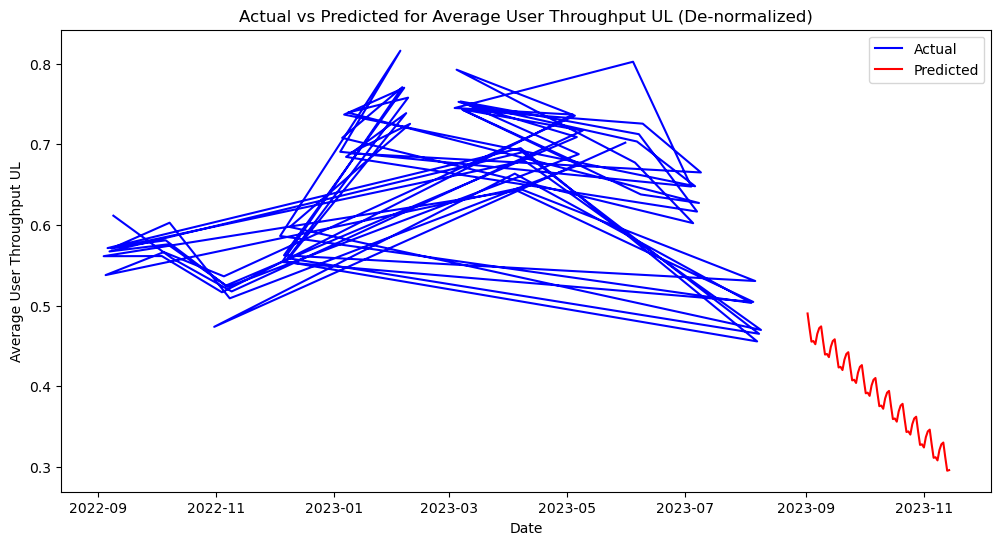

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:16:55 - cmdstanpy - INFO - Chain [1] start processing


Metrics for Average User Throughput UL:
MSE: 0.0726
MAE: 0.2485
MAPE: 37.5954
RMSE: 0.2695
R-squared: -7.3277
Forecast Bias: -0.2485
Processing column: CSSR


19:16:55 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


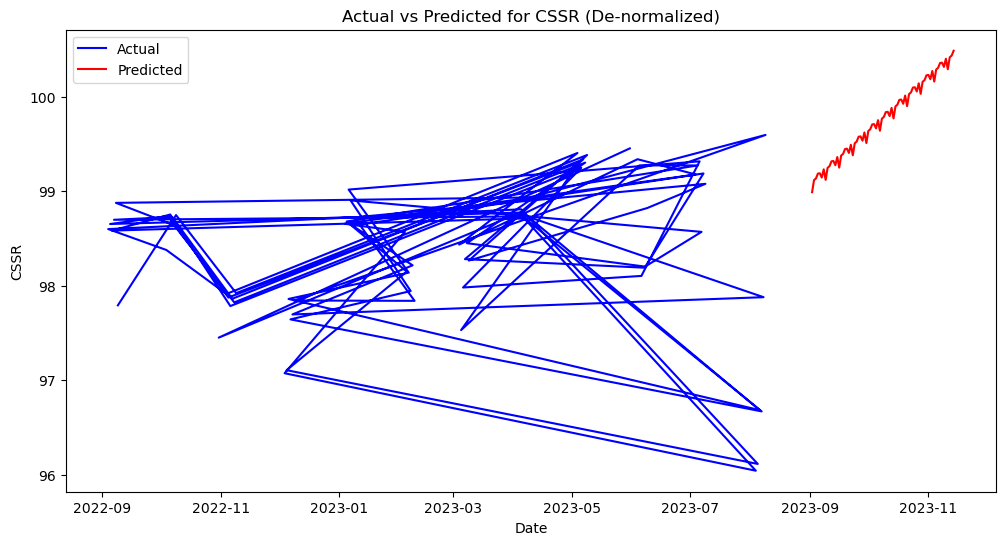

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:16:56 - cmdstanpy - INFO - Chain [1] start processing


Metrics for CSSR:
MSE: 2.5514
MAE: 1.3901
MAPE: 1.4183
RMSE: 1.5973
R-squared: -3.4168
Forecast Bias: 1.3712
Processing column: DL_256QAM_PROPORTION


19:16:56 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


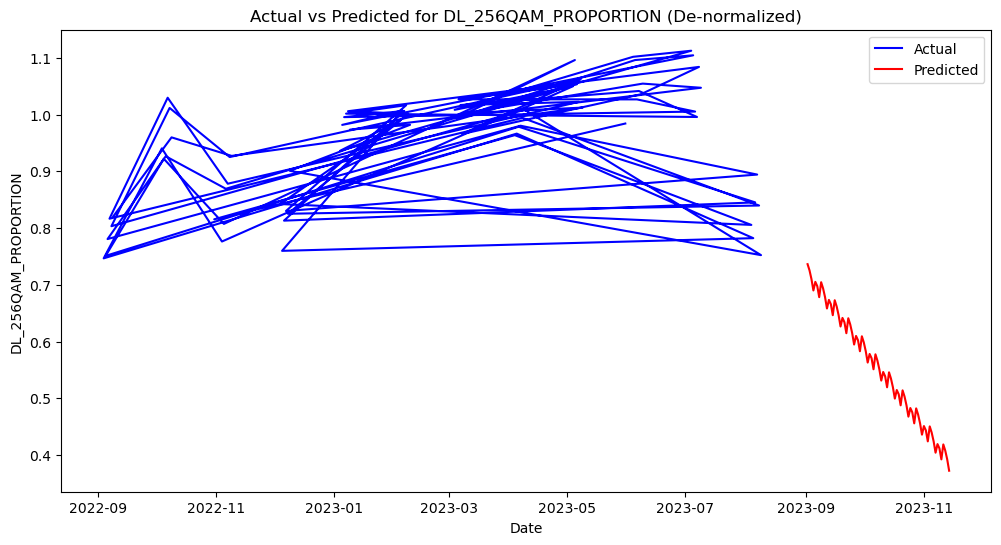

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:16:57 - cmdstanpy - INFO - Chain [1] start processing


Metrics for DL_256QAM_PROPORTION:
MSE: 0.1771
MAE: 0.3943
MAPE: 40.7269
RMSE: 0.4208
R-squared: -16.4951
Forecast Bias: -0.3943
Processing column: DL_LATENCY


19:16:57 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


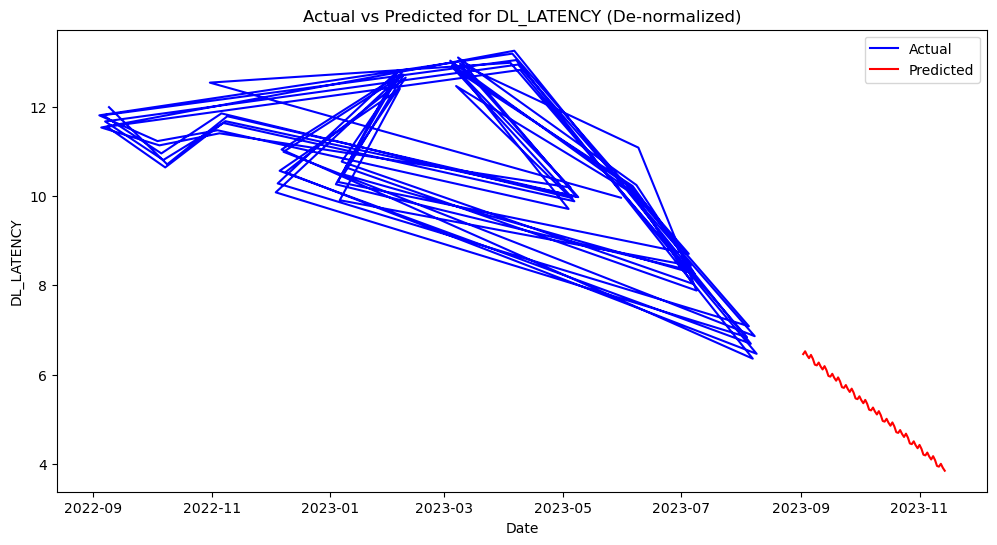

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:16:57 - cmdstanpy - INFO - Chain [1] start processing
19:16:57 - cmdstanpy - INFO - Chain [1] done processing


Metrics for DL_LATENCY:
MSE: 35.0018
MAE: 5.5775
MAPE: 50.0644
RMSE: 5.9162
R-squared: -9.8391
Forecast Bias: -5.5775
Processing column: DL_PACK_LOSS_RATE


C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


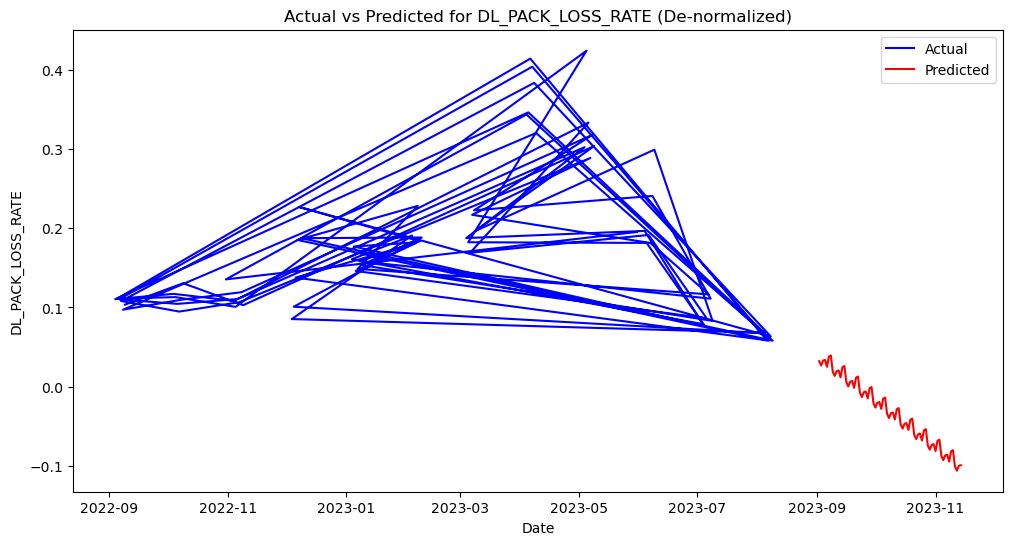

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:16:58 - cmdstanpy - INFO - Chain [1] start processing


Metrics for DL_PACK_LOSS_RATE:
MSE: 0.0527
MAE: 0.2056
MAPE: 122.7211
RMSE: 0.2297
R-squared: -5.1290
Forecast Bias: -0.2056
Processing column: DL_QPSK_PROPORTION


19:16:59 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


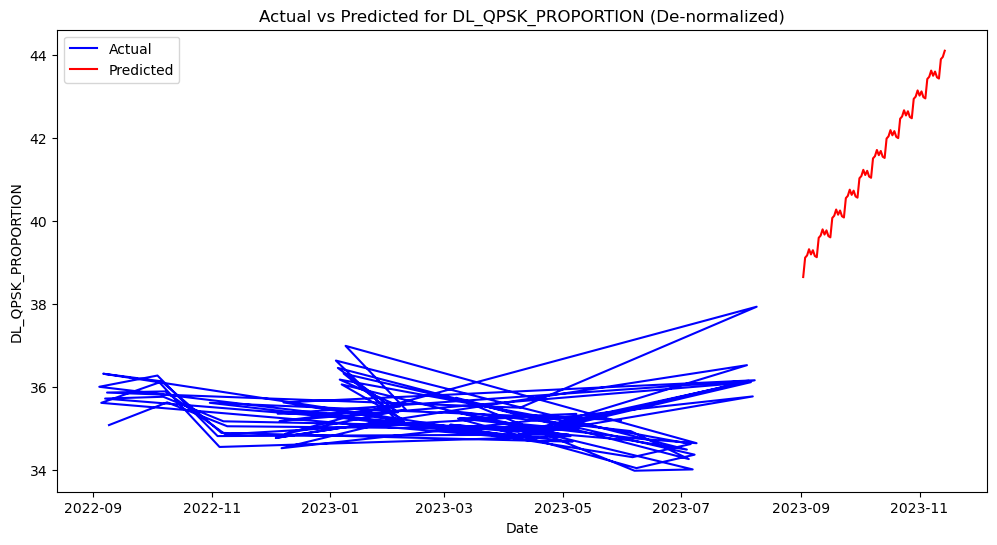

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:16:59 - cmdstanpy - INFO - Chain [1] start processing


Metrics for DL_QPSK_PROPORTION:
MSE: 39.8052
MAE: 6.0960
MAPE: 17.3060
RMSE: 6.3091
R-squared: -73.0904
Forecast Bias: 6.0960
Processing column: Data Volume DL


19:16:59 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


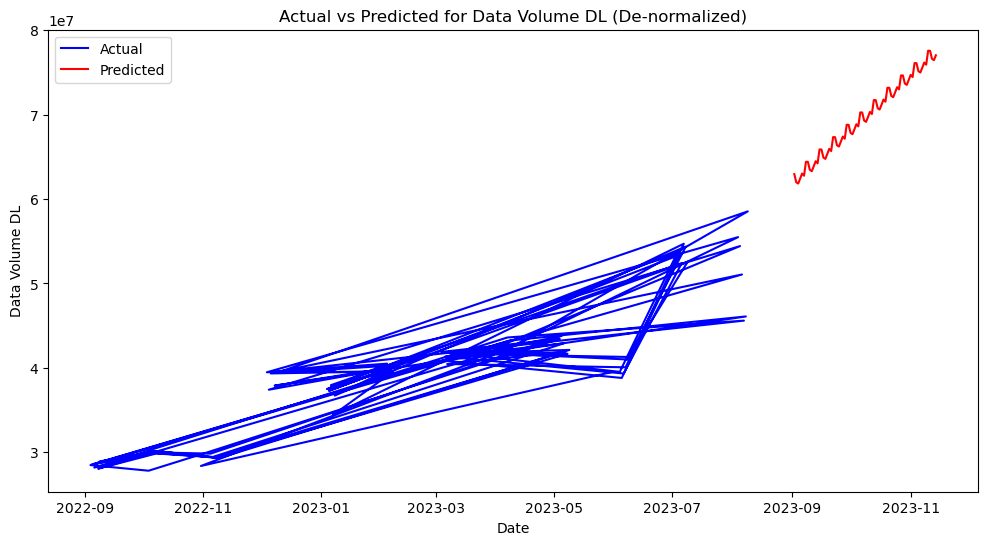

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:17:00 - cmdstanpy - INFO - Chain [1] start processing
19:17:00 - cmdstanpy - INFO - Chain [1] done processing


Metrics for Data Volume DL:
MSE: 1001720728132613.3750
MAE: 30281596.2520
MAPE: 83.9045
RMSE: 31649972.0084
R-squared: -15.4820
Forecast Bias: 30281596.2520
Processing column: User Count Maximum


C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


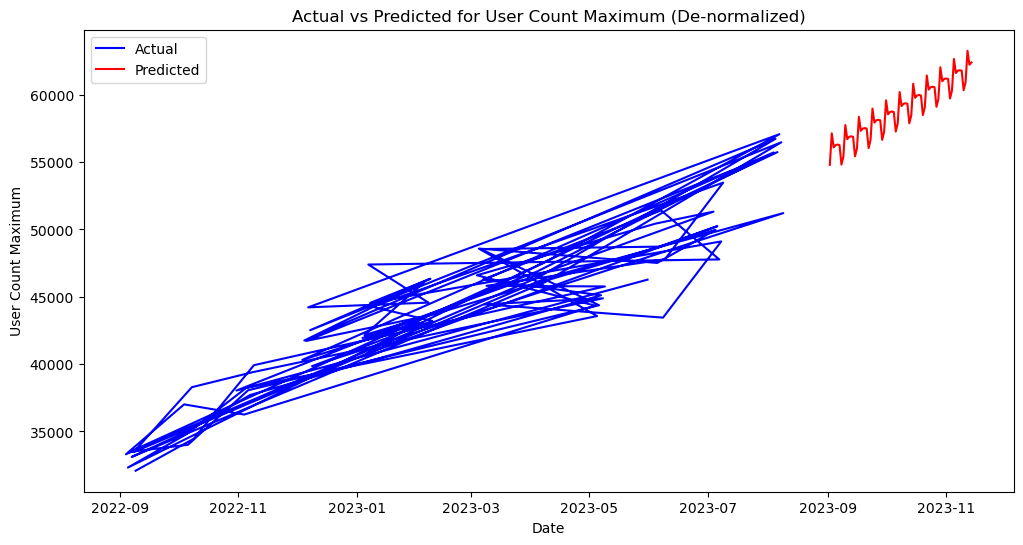

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:17:01 - cmdstanpy - INFO - Chain [1] start processing


Metrics for User Count Maximum:
MSE: 266896469.1089
MAE: 14893.7955
MAPE: 36.7162
RMSE: 16336.9663
R-squared: -5.9717
Forecast Bias: 14893.7955
Processing column: S1_SIG_SUCC


19:17:01 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


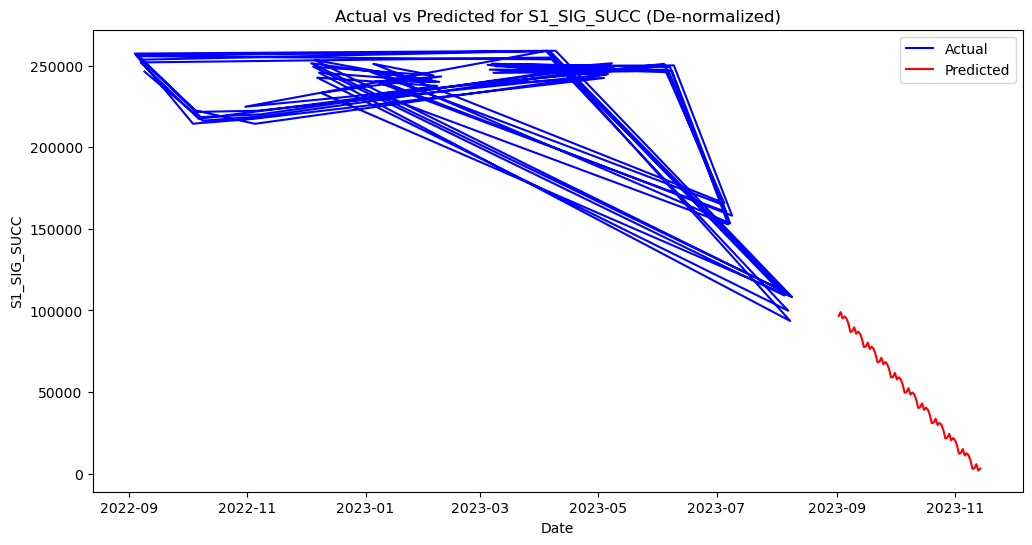

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:17:02 - cmdstanpy - INFO - Chain [1] start processing


Metrics for S1_SIG_SUCC:
MSE: 33090377694.0151
MAE: 174282.8989
MAPE: 76.2568
RMSE: 181907.6076
R-squared: -16.4789
Forecast Bias: -174282.8989
Processing column: TOTAL_DOWNTIME


19:17:02 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:5: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((actual - predicted) / actual)) * 100


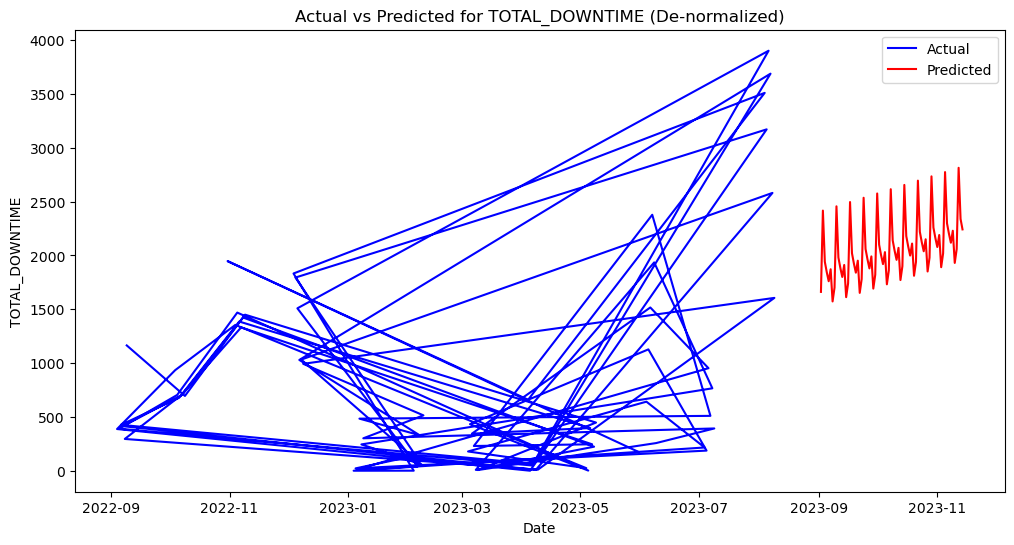

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:17:03 - cmdstanpy - INFO - Chain [1] start processing


Metrics for TOTAL_DOWNTIME:
MSE: 2441030.1176
MAE: 1424.7913
MAPE: inf
RMSE: 1562.3796
R-squared: -1.9798
Forecast Bias: 1237.9810
Processing column: Traffic


19:17:03 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


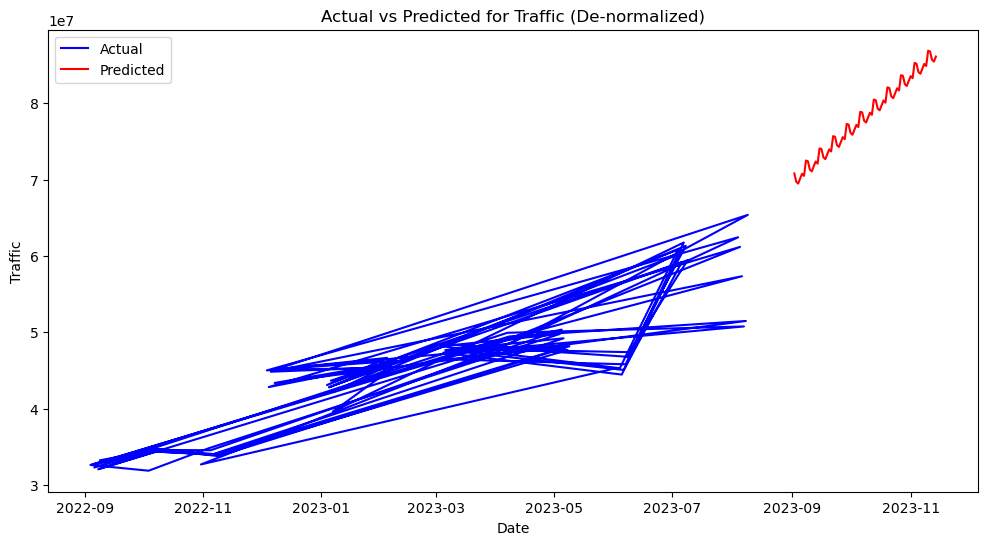

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:17:03 - cmdstanpy - INFO - Chain [1] start processing
19:17:04 - cmdstanpy - INFO - Chain [1] done processing


Metrics for Traffic:
MSE: 1196610232931405.0000
MAE: 33076241.8565
MAPE: 79.9670
RMSE: 34592054.4769
R-squared: -15.2269
Forecast Bias: 33076241.8565
Processing column: UL_QPSK_PROPORTION


C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


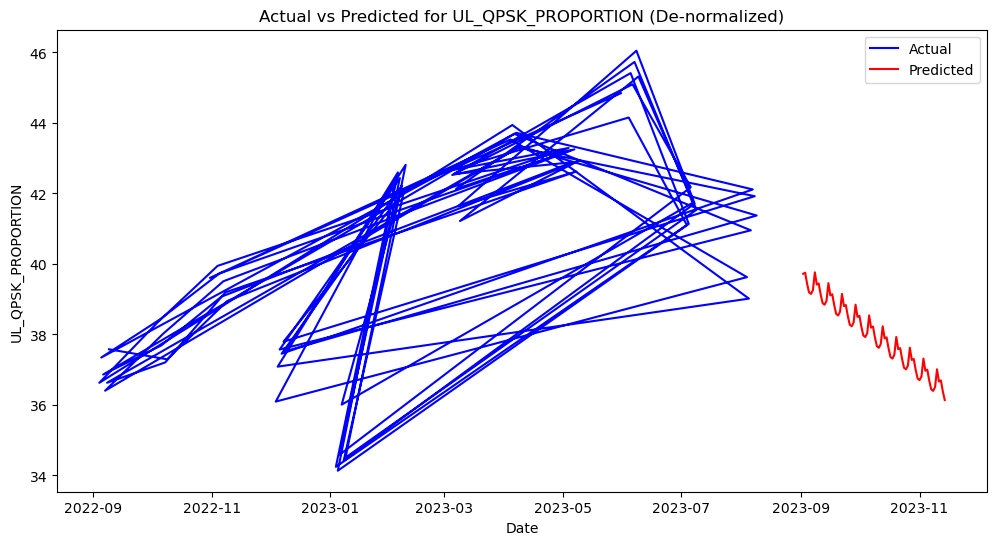

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['ds'] = pd.to_datetime(train['ds'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])
19:17:04 - cmdstanpy - INFO - Chain [1] start processing
19:17:04 - cmdstanpy - INFO - Chain [1] done processing


Metrics for UL_QPSK_PROPORTION:
MSE: 16.1968
MAE: 3.3602
MAPE: 8.0635
RMSE: 4.0245
R-squared: -0.6757
Forecast Bias: -2.4521
Processing column: UL_TRAFFIC_MB


C:\Users\HP\AppData\Local\Temp\ipykernel_8824\1957162335.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y'] *= max_value  # De-normalize actual values


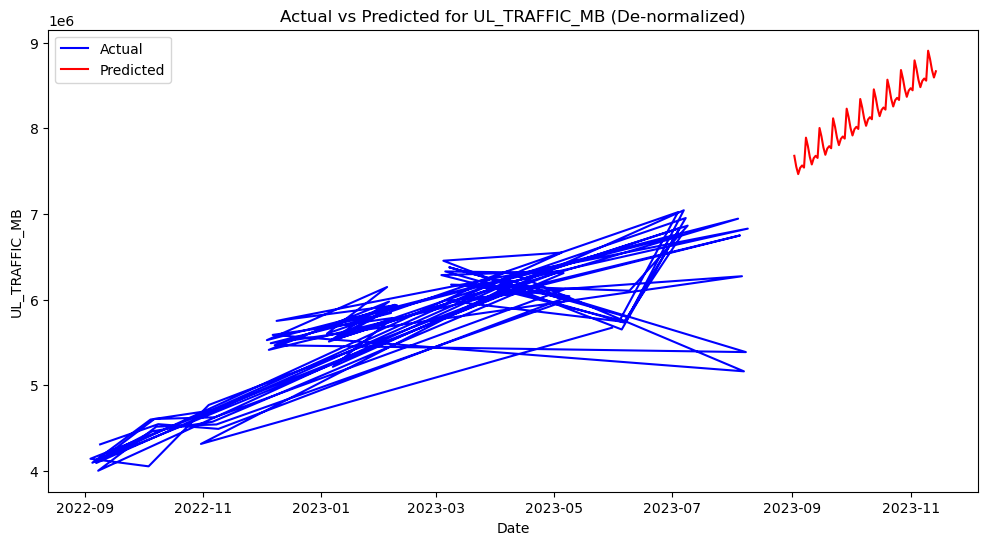

Metrics for UL_TRAFFIC_MB:
MSE: 7190308546542.1826
MAE: 2512414.5559
MAPE: 48.3009
RMSE: 2681475.0692
R-squared: -9.0330
Forecast Bias: 2512414.5559

Metrics saved to 'Prophet_Evaluation_Metrics.csv'


In [62]:

# Function to calculate evaluation metrics
def calculate_metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    rmse = np.sqrt(mse)
    r_squared = r2_score(actual, predicted)
    forecast_bias = np.mean(predicted - actual)
    return {
        "MSE": mse,
        "MAE": mae,
        "MAPE": mape,
        "RMSE": rmse,
        "R-squared": r_squared,
        "Forecast Bias": forecast_bias
    }

# Prepare the data for a given column
def prepare_data(data, column):
    data_prophet = data[['Date', column]].rename(columns={'Date': 'ds', column: 'y'})
    max_value = data_prophet['y'].max()
    data_prophet['y'] /= max_value
    return data_prophet, max_value

# Forecast using Prophet
def forecast_with_prophet(data, column):
    # Prepare data
    data_prophet, max_value = prepare_data(data, column)
    
    # Split into training and testing sets
    train_size = int(len(data_prophet) * 0.8)
    train, test = data_prophet.iloc[:train_size], data_prophet.iloc[train_size:]
    
    # Ensure the 'ds' column is in datetime format
    train['ds'] = pd.to_datetime(train['ds'])
    test['ds'] = pd.to_datetime(test['ds'])
    
    # Initialize and fit the model
    model = Prophet()
    model.fit(train)
    
    # Make future predictions
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Extract predictions
    test_predictions = forecast[['ds', 'yhat']].iloc[-len(test):]
    test_predictions['yhat'] *= max_value  # De-normalize predictions
    test['y'] *= max_value  # De-normalize actual values
    
    # Ensure 'ds' in test_predictions is in datetime format
    test_predictions['ds'] = pd.to_datetime(test_predictions['ds'])
    
    # Calculate metrics
    metrics = calculate_metrics(test['y'].values, test_predictions['yhat'].values)
    
    # Plot results
    plt.figure(figsize=(12, 6))
    plt.plot(test['ds'], test['y'], label='Actual', color='blue')
    plt.plot(test_predictions['ds'], test_predictions['yhat'], label='Predicted', color='red')
    plt.title(f'Actual vs Predicted for {column} (De-normalized)')
    plt.xlabel('Date')
    plt.ylabel(column)
    plt.legend()
    plt.show()
    
    return metrics

# Loop through each column and generate predictions
columns = [
    'Average User Throughput DL', 
    'Average User Throughput UL',
    'CSSR',
    'DL_256QAM_PROPORTION',
    'DL_LATENCY',
    'DL_PACK_LOSS_RATE',
    'DL_QPSK_PROPORTION',
    'Data Volume DL',
    'User Count Maximum',
    'S1_SIG_SUCC',
    'TOTAL_DOWNTIME',
    'Traffic',
    'UL_QPSK_PROPORTION',
    'UL_TRAFFIC_MB'
]

# Store results
results = {}

for column in columns:
    print(f"Processing column: {column}")
    metrics = forecast_with_prophet(data, column)
    print(f"Metrics for {column}:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    results[column] = metrics

# Save the metrics for all columns
import pandas as pd
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df.to_csv('Prophet_Evaluation_Metrics.csv')
print("\nMetrics saved to 'Prophet_Evaluation_Metrics.csv'")

C:\Users\HP\AppData\Local\Temp\ipykernel_8824\810800294.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['y_normalized'] = test['y'] / max_value  # Normalize actual


Evaluation Metrics (Normalized):
MSE: 0.002294
MAE: 0.029835
RMSE: 0.047898
MAPE: 3.33%
R-squared: -0.178624
MASE: 2.144739
Forecast Bias: -0.017500


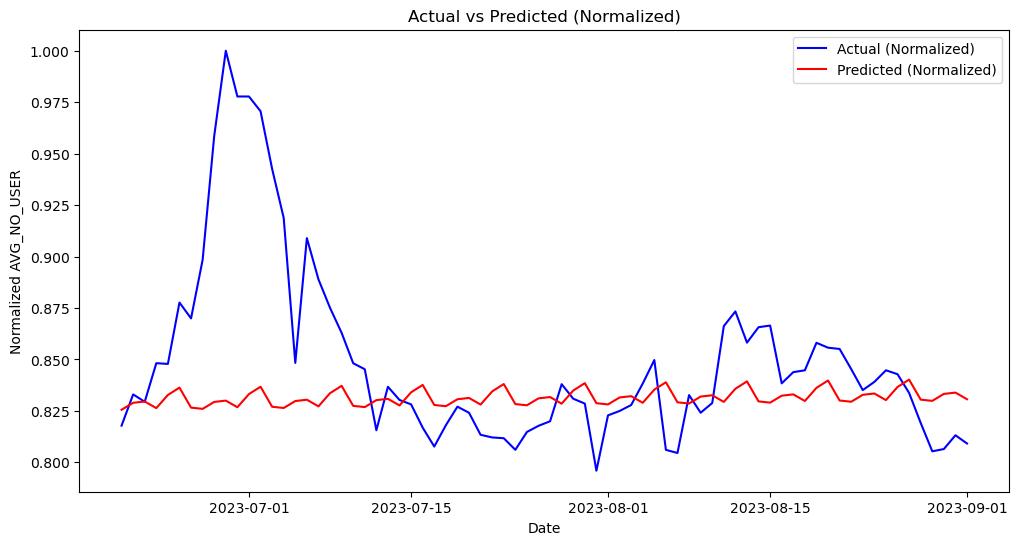

In [51]:
# Normalize data (divide by max value)
max_value = test['y'].max()
test['y_normalized'] = test['y'] / max_value  # Normalize actual
test_predictions['yhat_normalized'] = test_predictions['yhat'] / max_value  # Normalize predicted

# Recalculate evaluation metrics
def calculate_metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(actual, predicted)
    mase = mae / np.mean(np.abs(np.diff(actual)))  # MASE
    forecast_bias = np.mean(predicted - actual)
    return mse, mae, rmse, mape, r2, mase, forecast_bias

metrics = calculate_metrics(test['y_normalized'], test_predictions['yhat_normalized'])

# Display metrics
print("Evaluation Metrics (Normalized):")
print(f"MSE: {metrics[0]:.6f}")
print(f"MAE: {metrics[1]:.6f}")
print(f"RMSE: {metrics[2]:.6f}")
print(f"MAPE: {metrics[3]:.2f}%")
print(f"R-squared: {metrics[4]:.6f}")
print(f"MASE: {metrics[5]:.6f}")
print(f"Forecast Bias: {metrics[6]:.6f}")

# Plot normalized actual vs. predicted
plt.figure(figsize=(12, 6))
plt.plot(test['ds'], test['y_normalized'], label='Actual (Normalized)', color='blue')
plt.plot(test_predictions['ds'], test_predictions['yhat_normalized'], label='Predicted (Normalized)', color='red')
plt.title('Actual vs Predicted (Normalized)')
plt.xlabel('Date')
plt.ylabel('Normalized AVG_NO_USER')
plt.legend()
plt.show()

Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.23080864765910963
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.23080864765910963
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.03195585296716754
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.03195585296716754
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.01317600859138989
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.01317600859138989
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.3542831377818642
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.3149190092981354
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.3427594726813366
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.1235761096196439
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.39302215092958454
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.08648342829794978
Training

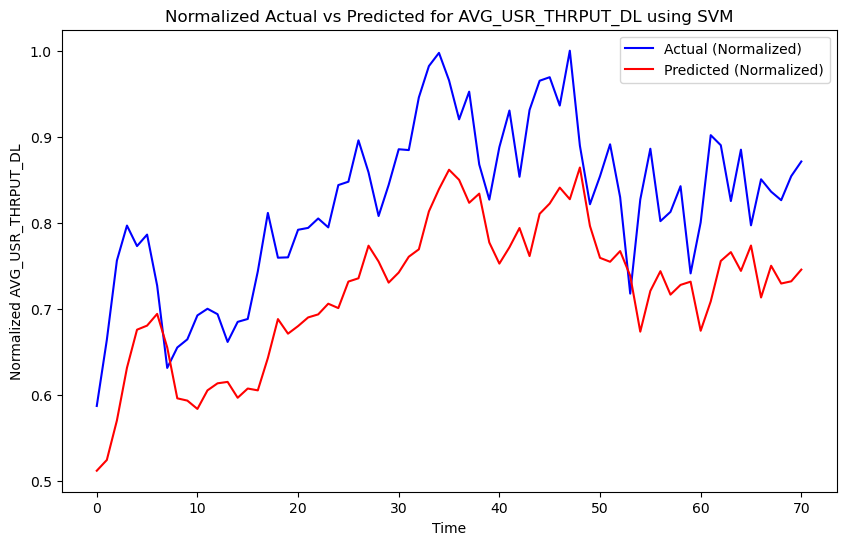

In [70]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area3.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'AVG_USR_THRPUT_DL'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.012883622376397109
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.012883622376397109
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.006446489851100472
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.006446489851100472
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.004331244809997847
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.004331244809997847
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.020019004478182174
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.014322352379421291
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.030239646178131196
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.00639487605203085
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.023687473864966203
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.002106825979

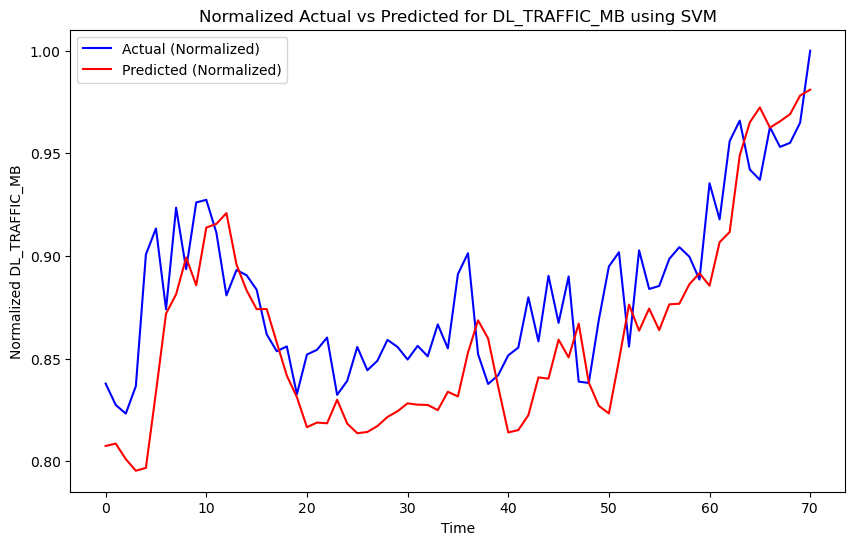

In [72]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area4.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [2]:
from sklearn.svm import SVR
from sklearn.preprocessing import MaxAbsScaler

from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Dense, GRU, Dropout



In [3]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area1.csv')

In [4]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]


Epoch 1/50
9/9 [==============================] - 15s 330ms/step - loss: 0.1510 - val_loss: 0.0047
Epoch 2/50
9/9 [==============================] - 0s 19ms/step - loss: 0.0317 - val_loss: 0.0019
Epoch 3/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0072 - val_loss: 0.0163
Epoch 4/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0088 - val_loss: 2.7009e-04
Epoch 5/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0057 - val_loss: 2.5521e-04
Epoch 6/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0047 - val_loss: 0.0020
Epoch 7/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0043 - val_loss: 2.4821e-04
Epoch 8/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0043 - val_loss: 8.0935e-04
Epoch 9/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0041 - val_loss: 7.7109e-04
Epoch 10/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0039 - val_loss: 5.7535e-04
Epoch

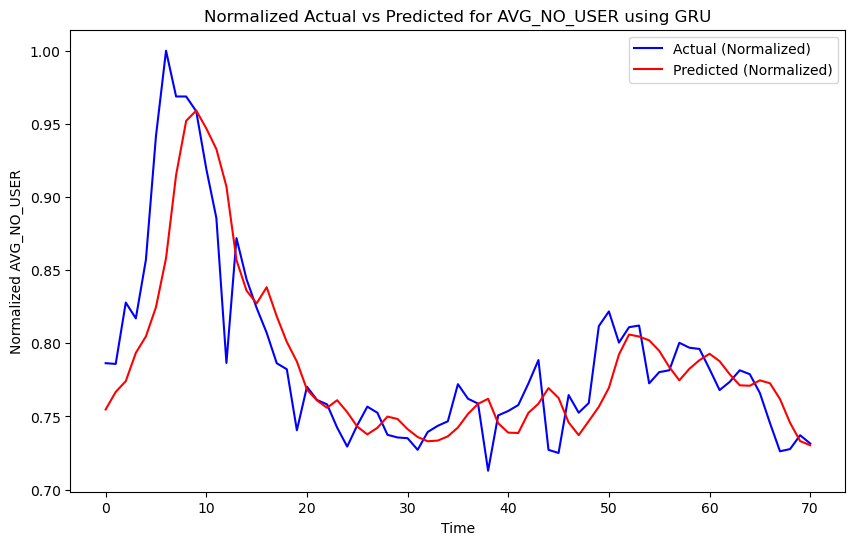

In [5]:
# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)
# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

In [7]:
# Calculate MAE, MAPE, RMSE, and R-squared
gru_mae = mean_absolute_error(y_test, test_predict_gru)
gru_mape = np.mean(np.abs((y_test - test_predict_gru) / y_test)) * 100  # MAPE in percentage
gru_rmse = np.sqrt(mean_squared_error(y_test, test_predict_gru))  # RMSE
gru_r2 = r2_score(y_test, test_predict_gru)  # R-squared

# Print all evaluation metrics
print(f'GRU Model Metrics:')
print(f'GRU Model MSE (Normalized): {gru_mse}')
print(f'MAE: {gru_mae}')
print(f'MAPE: {gru_mape}%')
print(f'RMSE: {gru_rmse}')
print(f'R-squared: {gru_r2}')

GRU Model Metrics:
GRU Model MSE (Normalized): 0.0012570989539578427
MAE: 0.02364772433755504
MAPE: 7.195796922445412%
RMSE: 0.035455591293304396
R-squared: 0.6832677814477219


In [8]:
def calculate_mase(y_true, y_pred, y_train):
    # Calculate the mean absolute error of the naive forecast (previous time step)
    naive_forecast = y_train[:-1]
    naive_errors = np.abs(y_train[1:] - naive_forecast)
    q = np.mean(naive_errors)
    
    # Calculate the mean absolute error of the predictions
    mae = np.mean(np.abs(y_true - y_pred))
    
    # MASE calculation
    mase = mae / q
    
    return mase

# Assuming you have:
# y_true: actual test values
# y_pred: predicted test values
# y_train: original training data
gru_mase = calculate_mase(y_test, test_predict_gru, y_train)
print(f'MASE: {gru_mase}')


MASE: 2.4817182500281794


In [9]:
# Enhanced Dataset Creation Function
def create_dataset_gru(dataset, look_back=1, forecast_horizon=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back - forecast_horizon + 1):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back + forecast_horizon - 1, 0])
    return np.array(X), np.array(Y)

# Advanced MASE Calculation with Multiple Naive Forecast Methods
def calculate_advanced_mase(y_true, y_pred, y_train, method='moving_average', window=3):
    # Multiple naive forecast strategies
    if method == 'moving_average':
        naive_forecast = np.convolve(y_train, np.ones(window)/window, 'valid')
        naive_forecast = naive_forecast[:-window+1]
    elif method == 'seasonal_naive':
        # Adjust seasonal period based on your data characteristics
        seasonal_period = max(4, len(y_train) // 12)
        naive_forecast = y_train[-seasonal_period:]
    else:
        # Simple previous step naive forecast
        naive_forecast = y_train[:-1]
    
    # Handle potential zero division
    naive_errors = np.abs(y_train[1:len(naive_forecast)+1] - naive_forecast)
    q = np.mean(naive_errors) if np.mean(naive_errors) != 0 else 1e-10
    
    mae = np.mean(np.abs(y_true - y_pred))
    mase = mae / q
    
    return mase

# Enhanced Model Architecture
def build_advanced_gru_model(input_shape, layers_config=None):
    if layers_config is None:
        layers_config = {
            'gru_layers': [
                {'units': 128, 'return_sequences': True},
                {'units': 64, 'return_sequences': False}
            ],
            'dropout_rates': [0.3, 0.2],
            'dense_layers': [32, 16]
        }
    
    model = Sequential()
    
    # First GRU Layer
    model.add(GRU(
        layers_config['gru_layers'][0]['units'], 
        return_sequences=layers_config['gru_layers'][0]['return_sequences'], 
        input_shape=input_shape
    ))
    model.add(Dropout(layers_config['dropout_rates'][0]))
    
    # Second GRU Layer
    model.add(GRU(
        layers_config['gru_layers'][1]['units'], 
        return_sequences=layers_config['gru_layers'][1]['return_sequences']
    ))
    model.add(Dropout(layers_config['dropout_rates'][1]))
    
    # Dense Layers
    for units in layers_config['dense_layers']:
        model.add(Dense(units, activation='relu'))
    
    model.add(Dense(1))
    
    # Advanced Optimization
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    return model

# Main Execution Function
def train_and_evaluate_gru(data, feature='AVG_NO_USER'):
    # Preprocessing
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data[[feature]])
    
    # Advanced Data Preparation
    train_size = int(len(scaled_data) * 0.8)
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Hyperparameter Tuning
    look_back_options = [3, 5, 7]
    forecast_horizon_options = [1, 2]
    
    best_mase = float('inf')
    best_config = {}
    
    for look_back in look_back_options:
        for forecast_horizon in forecast_horizon_options:
            # Create datasets
            X_train, y_train = create_dataset_gru(train, look_back=look_back, forecast_horizon=forecast_horizon)
            X_test, y_test = create_dataset_gru(test, look_back=look_back, forecast_horizon=forecast_horizon)
            
            # Reshape for GRU
            X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
            X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
            
            # Callbacks
            early_stopping = EarlyStopping(
                monitor='val_loss', 
                patience=10, 
                restore_best_weights=True
            )
            
            reduce_lr = ReduceLROnPlateau(
                monitor='val_loss', 
                factor=0.2, 
                patience=5, 
                min_lr=0.00001
            )
            
            # Model Training
            gru_model = build_advanced_gru_model((look_back, 1))
            gru_model.fit(
                X_train, y_train, 
                epochs=100, 
                batch_size=32, 
                validation_split=0.2, 
                callbacks=[early_stopping, reduce_lr],
                verbose=0
            )
            
            # Predictions
            train_predict_gru = gru_model.predict(X_train)
            test_predict_gru = gru_model.predict(X_test)
            
            # MASE Calculation with Multiple Methods
            mase_methods = ['simple', 'moving_average', 'seasonal_naive']
            for method in mase_methods:
                current_mase = calculate_advanced_mase(y_test, test_predict_gru, y_train, method=method)
                
                if current_mase < best_mase:
                    best_mase = current_mase
                    best_config = {
                        'look_back': look_back,
                        'forecast_horizon': forecast_horizon,
                        'mase_method': method,
                        'mase_score': current_mase
                    }
    
    # Print Best Configuration
    print("Best Configuration:")
    for key, value in best_config.items():
        print(f"{key}: {value}")
    
    return best_config

# Assuming 'data' is your DataFrame
# result = train_and_evaluate_gru(data)

In [10]:
# Import necessary libraries
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score, 
    mean_absolute_percentage_error,
    explained_variance_score
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inverse transform predictions and actual values
def inverse_transform_predictions(scaler, y_pred, y_true):
    # Reshape predictions and true values if needed
    y_pred_reshaped = y_pred.reshape(-1, 1)
    y_true_reshaped = y_true.reshape(-1, 1)
    
    # Inverse transform
    y_pred_original = scaler.inverse_transform(y_pred_reshaped)
    y_true_original = scaler.inverse_transform(y_true_reshaped)
    
    return y_pred_original, y_true_original

# Comprehensive Evaluation Metrics Function
def comprehensive_model_evaluation(y_true, y_pred, y_train, scaler=None):
    # If scaler is provided, inverse transform the predictions
    if scaler is not None:
        y_pred_original, y_true_original = inverse_transform_predictions(scaler, y_pred, y_true)
    else:
        y_pred_original, y_true_original = y_pred, y_true
    
    # Calculate Metrics
    metrics = {
        'Mean Absolute Error (MAE)': mean_absolute_error(y_true, y_pred),
        'Mean Squared Error (MSE)': mean_squared_error(y_true, y_pred),
        'Root Mean Squared Error (RMSE)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'Mean Absolute Percentage Error (MAPE)': np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        'R-squared (R2)': r2_score(y_true, y_pred),
        'Explained Variance Score': explained_variance_score(y_true, y_pred),
        'MASE': calculate_advanced_mase(y_true, y_pred, y_train)
    }
    
    # Print Metrics
    print("Model Evaluation Metrics:")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value}")
    
    return metrics

# Visualization Functions
def plot_actual_vs_predicted(y_true, y_pred, title='Actual vs Predicted'):
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label='Actual', color='blue')
    plt.plot(y_pred, label='Predicted', color='red')
    plt.title(title)
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

def plot_residuals(y_true, y_pred):
    residuals = y_true - y_pred
    
    # Residual Plot
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.scatter(y_pred, residuals)
    plt.title('Residuals vs Predicted')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.axhline(y=0, color='r', linestyle='--')
    
    # Residual Histogram
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black')
    plt.title('Residuals Distribution')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

def error_distribution_plot(y_true, y_pred):
    errors = np.abs(y_true - y_pred)
    
    plt.figure(figsize=(10, 6))
    sns.histplot(errors, kde=True)
    plt.title('Error Distribution')
    plt.xlabel('Absolute Error')
    plt.ylabel('Frequency')
    plt.show()

# Main Execution
def model_comprehensive_analysis(y_test, test_predict_gru, y_train, scaler=None):
    # Comprehensive Metrics
    metrics = comprehensive_model_evaluation(y_test, test_predict_gru, y_train, scaler)
    
    # Visualizations
    plot_actual_vs_predicted(y_test, test_predict_gru, 'GRU Model: Actual vs Predicted')
    plot_residuals(y_test, test_predict_gru)
    error_distribution_plot(y_test, test_predict_gru)
    
    return metrics

# Call the analysis function
# Make sure to pass your test predictions, test true values, and training data
# model_comprehensive_analysis(y_test, test_predict_gru, y_train, scaler)

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

Epoch 1/50
8/8 [==============================] - 7s 147ms/step - loss: 0.2210 - val_loss: 0.0317
Epoch 2/50
8/8 [==============================] - 0s 12ms/step - loss: 0.0207 - val_loss: 0.0323
Epoch 3/50
8/8 [==============================] - 0s 12ms/step - loss: 0.0191 - val_loss: 0.0068
Epoch 4/50
8/8 [==============================] - 0s 14ms/step - loss: 0.0111 - val_loss: 0.0163
Epoch 5/50
8/8 [==============================] - 0s 15ms/step - loss: 0.0075 - val_loss: 0.0016
Epoch 6/50
8/8 [==============================] - 0s 14ms/step - loss: 0.0055 - val_loss: 0.0015
Epoch 7/50
8/8 [==============================] - 0s 14ms/step - loss: 0.0046 - val_loss: 0.0040
Epoch 8/50
8/8 [==============================] - 0s 13ms/step - loss: 0.0047 - val_loss: 0.0031
Epoch 9/50
8/8 [==============================] - 0s 13ms/step - loss: 0.0045 - val_loss: 0.0021
Epoch 10/50
8/8 [==============================] - 0s 14ms/step - loss: 0.0044 - val_loss: 0.0021
Epoch 11/50
8/8 [===========

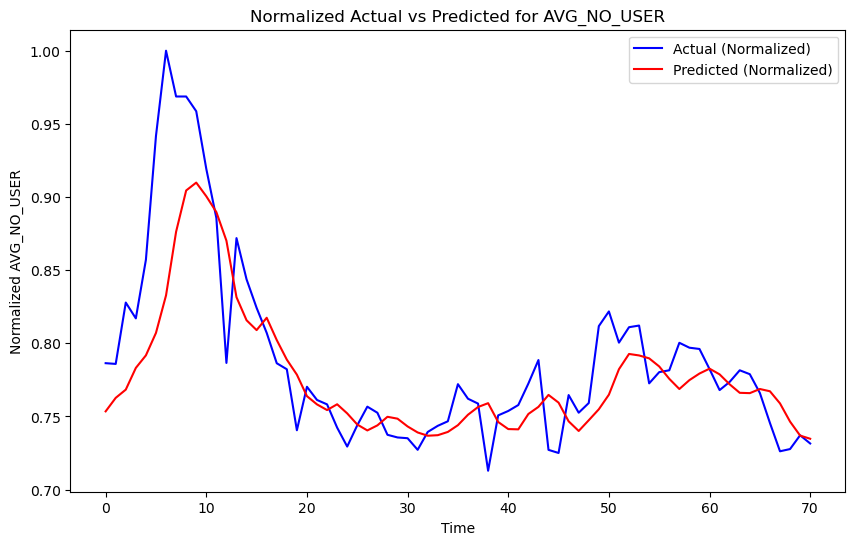

In [12]:
# Feature selection
feature = 'AVG_NO_USER'  # Confirm this is the correct column name

# Preprocessing
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split data
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Dataset creation function
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Prepare data
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Model definition
def build_gru_model(input_shape):
    model = Sequential([
        GRU(100, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(50, return_sequences=False),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    return model

# Train model
gru_model = build_gru_model((look_back, 1))
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

gru_model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2, 
    callbacks=[early_stopping],
    verbose=1
)

# Prediction
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# MASE Calculation
def calculate_mase(y_true, y_pred, y_train):
    naive_forecast = y_train[:-1]
    naive_errors = np.abs(y_train[1:] - naive_forecast)
    q = np.mean(naive_errors)
    
    mae = np.mean(np.abs(y_true - y_pred))
    mase = mae / q
    
    return mase

# Evaluation Metrics
gru_mse = mean_squared_error(y_test, test_predict_gru)
gru_mae = mean_absolute_error(y_test, test_predict_gru)
gru_mape = np.mean(np.abs((y_test - test_predict_gru) / y_test)) * 100
gru_rmse = np.sqrt(mean_squared_error(y_test, test_predict_gru))
gru_r2 = r2_score(y_test, test_predict_gru)
gru_mase = calculate_mase(y_test, test_predict_gru, y_train)

# Print Metrics
print(f'GRU Model Metrics:')
print(f'MSE (Normalized): {gru_mse}')
print(f'MAE: {gru_mae}')
print(f'MAPE: {gru_mape}%')
print(f'RMSE: {gru_rmse}')
print(f'R-squared: {gru_r2}')
print(f'MASE: {gru_mase}')

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature}')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

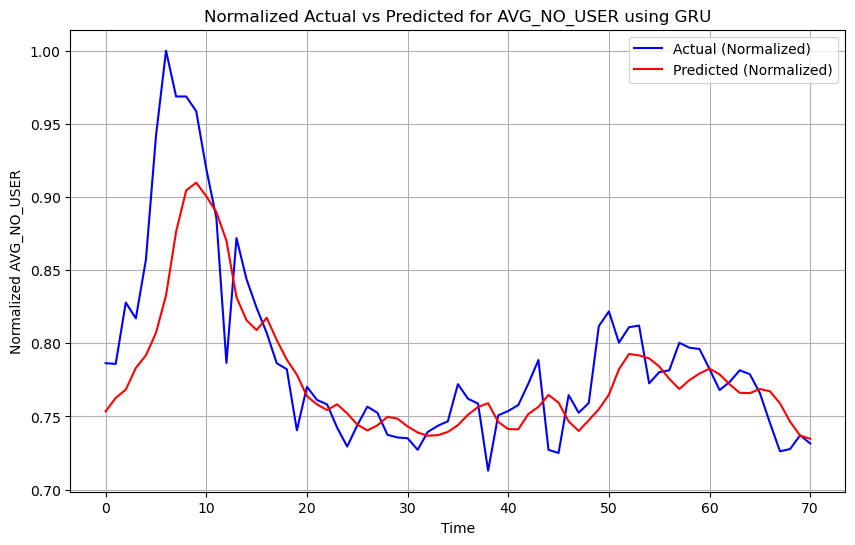

In [13]:
# Plot the GRU model's predictions with actual values (enhanced with labels for clarity)
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
data

,Date,AVG_NO_USER,AVG_USR_THRPUT_DL,DL_TRAFFIC_MB
0,2022-09-01 00:00:00,6919.59,649.73,15926000.77
1,2022-09-02 00:00:00,6916.80,716.17,15888133.90
2,2022-09-03 00:00:00,6852.06,740.46,14982246.10
3,2022-09-04 00:00:00,6846.14,715.02,15768670.80
4,2022-09-05 00:00:00,6784.53,781.21,15351915.55
...,...,...,...,...
361,2023-08-28 00:00:00,9044.90,3267.01,25373601.86
362,2023-08-29 00:00:00,8892.82,3037.00,23986359.10
363,2023-08-30 00:00:00,8904.82,3130.67,24443806.05
364,2023-08-31 00:00:00,8978.82,3127.35,25278187.70


Epoch 1/50
9/9 [==============================] - 6s 128ms/step - loss: 0.0112 - val_loss: 3.7962e-04
Epoch 2/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0050 - val_loss: 0.0068
Epoch 3/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0037 - val_loss: 6.7293e-04
Epoch 4/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0028 - val_loss: 8.8094e-04
Epoch 5/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0025 - val_loss: 4.0831e-04
Epoch 6/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0024 - val_loss: 2.8280e-04
Epoch 7/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0025 - val_loss: 6.0424e-04
Epoch 8/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0025 - val_loss: 2.7266e-04
Epoch 9/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0024 - val_loss: 3.7441e-04
Epoch 10/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0024 - val_loss: 3.1

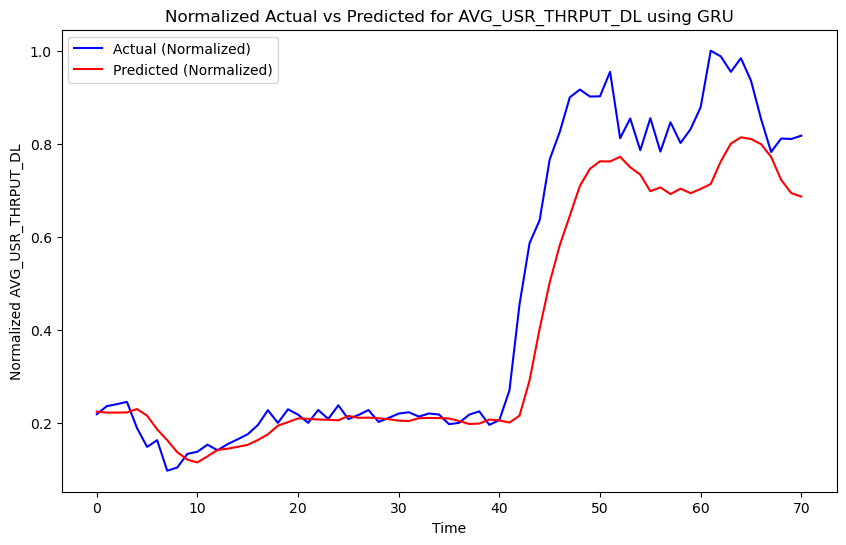

In [15]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [16]:
# Calculate MAE, MAPE, RMSE, and R-squared
gru_mae = mean_absolute_error(y_test, test_predict_gru)
gru_mape = np.mean(np.abs((y_test - test_predict_gru) / y_test)) * 100  # MAPE in percentage
gru_rmse = np.sqrt(mean_squared_error(y_test, test_predict_gru))  # RMSE
gru_r2 = r2_score(y_test, test_predict_gru)  # R-squared

# Print all evaluation metrics
print(f'GRU Model Metrics:')
print(f'GRU Model MSE (Normalized): {gru_mse}')
print(f'MAE: {gru_mae}')
print(f'MAPE: {gru_mape}%')
print(f'RMSE: {gru_rmse}')
print(f'R-squared: {gru_r2}')

GRU Model Metrics:
GRU Model MSE (Normalized): 0.012897319205740389
MAE: 0.07615105390540548
MAPE: 91.98860205821919%
RMSE: 0.11356636476413423
R-squared: 0.8764493010829985


Epoch 1/50
9/9 [==============================] - 9s 152ms/step - loss: 0.0175 - val_loss: 0.0125
Epoch 2/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0054 - val_loss: 4.7447e-04
Epoch 3/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0051 - val_loss: 0.0055
Epoch 4/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0043 - val_loss: 0.0043
Epoch 5/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0036 - val_loss: 9.7805e-04
Epoch 6/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0031 - val_loss: 0.0019
Epoch 7/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0027 - val_loss: 4.1599e-04
Epoch 8/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0027 - val_loss: 7.6325e-04
Epoch 9/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0026 - val_loss: 3.1523e-04
Epoch 10/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0025 - val_loss: 5.1466e-04
Epoc

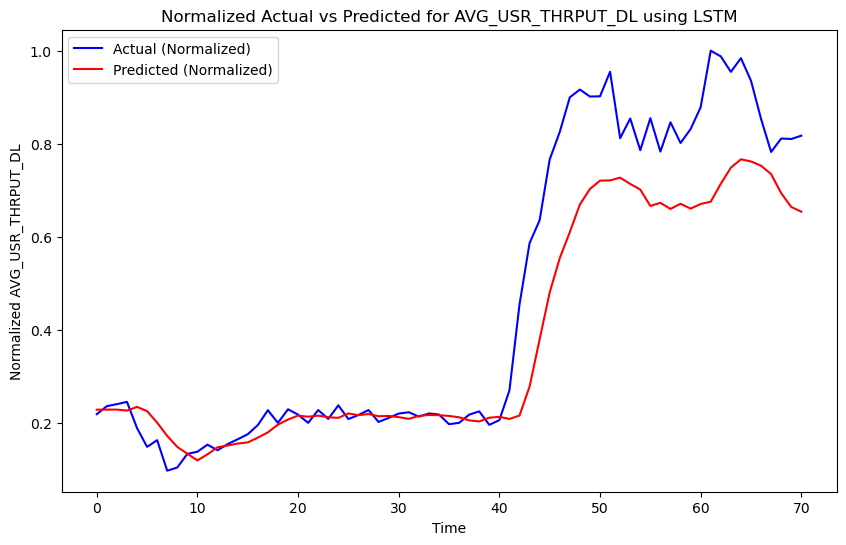

LSTM Model Metrics:
MSE (Normalized): 0.017633505882431517
MAE: 0.08948026801271583
MAPE: 87.88913388744263%
RMSE: 0.13279121161594812
R-squared: 0.8310786961710774
MASE: 4.124171117649256


In [19]:
# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

# Calculate MAE, MAPE, RMSE, and R-squared
lstm_mae = mean_absolute_error(y_test, test_predict_lstm)
lstm_mape = np.mean(np.abs((y_test - test_predict_lstm) / y_test)) * 100  # MAPE in percentage
lstm_rmse = np.sqrt(mean_squared_error(y_test, test_predict_lstm))  # RMSE
lstm_r2 = r2_score(y_test, test_predict_lstm)  # R-squared

# Calculate MASE
def calculate_mase(y_true, y_pred, y_train):
    naive_forecast = y_train[:-1]
    naive_errors = np.abs(y_train[1:] - naive_forecast)
    q = np.mean(naive_errors)
    
    mae = np.mean(np.abs(y_true - y_pred))
    mase = mae / (q + 1e-10)  # Add small value to avoid division by zero
    return mase

lstm_mase = calculate_mase(y_test.flatten(), test_predict_lstm.flatten(), y_train.flatten())

# Print all evaluation metrics
print(f'LSTM Model Metrics:')
print(f'MSE (Normalized): {lstm_mse}')
print(f'MAE: {lstm_mae}')
print(f'MAPE: {lstm_mape}%')
print(f'RMSE: {lstm_rmse}')
print(f'R-squared: {lstm_r2}')
print(f'MASE: {lstm_mase}')

Epoch 1/50
9/9 [==============================] - 7s 188ms/step - loss: 0.2451 - val_loss: 0.0059
Epoch 2/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0372 - val_loss: 0.0195
Epoch 3/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0140 - val_loss: 0.0173
Epoch 4/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0150 - val_loss: 0.0074
Epoch 5/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0083 - val_loss: 6.7407e-04
Epoch 6/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0089 - val_loss: 0.0012
Epoch 7/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0078 - val_loss: 0.0030
Epoch 8/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0077 - val_loss: 8.9191e-04
Epoch 9/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0070 - val_loss: 0.0014
Epoch 10/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0075 - val_loss: 0.0015
Epoch 11/50
9/9 [===

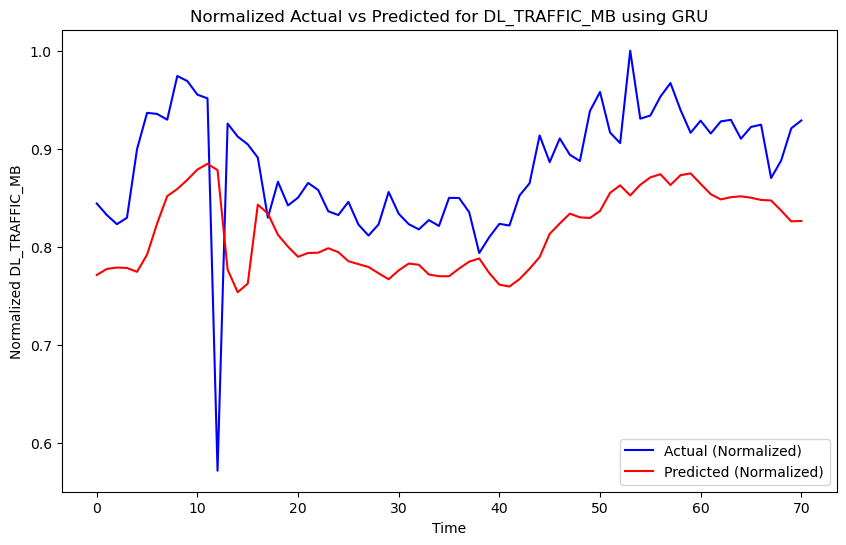

In [20]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [21]:
# Calculate MAE, MAPE, RMSE, and R-squared
gru_mae = mean_absolute_error(y_test, test_predict_gru)
gru_mape = np.mean(np.abs((y_test - test_predict_gru) / y_test)) * 100  # MAPE in percentage
gru_rmse = np.sqrt(mean_squared_error(y_test, test_predict_gru))  # RMSE
gru_r2 = r2_score(y_test, test_predict_gru)  # R-squared

# Print all evaluation metrics
print(f'GRU Model Metrics:')
print(f'GRU Model MSE (Normalized): {gru_mse}')
print(f'MAE: {gru_mae}')
print(f'MAPE: {gru_mape}%')
print(f'RMSE: {gru_rmse}')
print(f'R-squared: {gru_r2}')

GRU Model Metrics:
GRU Model MSE (Normalized): 0.007470835155846586
MAE: 0.07515121573008397
MAPE: 9.227004600541488%
RMSE: 0.0864339930573995
R-squared: -0.9266937351266349


In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [23]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'DL_TRAFFIC_MB'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(Bidirectional(GRU(150, return_sequences=True, input_shape=input_shape)))
    model.add(Dropout(0.2))
    model.add(GRU(100, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build the GRU model
gru_model = build_gru_model((look_back, 1))

# Add early stopping and learning rate scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the GRU model
gru_model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.1, 
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate metrics on normalized data
gru_mse = mean_squared_error(y_test, test_predict_gru)
gru_mae = mean_absolute_error(y_test, test_predict_gru)
gru_mape = np.mean(np.abs((y_test - test_predict_gru) / y_test)) * 100  # MAPE in percentage
gru_rmse = np.sqrt(mean_squared_error(y_test, test_predict_gru))
gru_r2 = r2_score(y_test, test_predict_gru)

# Print metrics
print(f'GRU Model Metrics:')
print(f'MSE (Normalized): {gru_mse}')
print(f'MAE: {gru_mae}')
print(f'MAPE: {gru_mape}%')
print(f'RMSE: {gru_rmse}')
print(f'R-squared: {gru_r2}')

Epoch 1/50
9/9 [==============================] - 17s 319ms/step - loss: 0.1599 - val_loss: 0.0533 - lr: 0.0010
Epoch 2/50
9/9 [==============================] - 0s 29ms/step - loss: 0.0250 - val_loss: 0.0369 - lr: 0.0010
Epoch 3/50
9/9 [==============================] - 0s 33ms/step - loss: 0.0143 - val_loss: 0.0042 - lr: 0.0010
Epoch 4/50
9/9 [==============================] - 0s 32ms/step - loss: 0.0104 - val_loss: 0.0064 - lr: 0.0010
Epoch 5/50
9/9 [==============================] - 0s 32ms/step - loss: 0.0080 - val_loss: 4.8759e-04 - lr: 0.0010
Epoch 6/50
9/9 [==============================] - 0s 25ms/step - loss: 0.0079 - val_loss: 0.0027 - lr: 0.0010
Epoch 7/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0083 - val_loss: 0.0013 - lr: 0.0010
Epoch 8/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0075 - val_loss: 0.0017 - lr: 0.0010
Epoch 9/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0074 - val_loss: 9.9722e-04 - lr: 5.0000e

In [24]:
from tensorflow.keras.layers import Attention

In [25]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional, Attention
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [26]:
# Adding lag features for feature engineering
data['DL_TRAFFIC_MB_LAG1'] = data['DL_TRAFFIC_MB'].shift(1)
data['DL_TRAFFIC_MB_LAG2'] = data['DL_TRAFFIC_MB'].shift(2)
data['DL_TRAFFIC_MB_LAG3'] = data['DL_TRAFFIC_MB'].shift(3)

# Fill NaN values created by lagging
data = data.fillna(method='bfill')

In [27]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back)])
        Y.append(dataset[i + look_back, 0])  # First column is target
    return np.array(X), np.array(Y)

# Preparing data for 'DL_TRAFFIC_MB'
features = ['DL_TRAFFIC_MB', 'DL_TRAFFIC_MB_LAG1', 'DL_TRAFFIC_MB_LAG2', 'DL_TRAFFIC_MB_LAG3']
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[features])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(features)))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], len(features)))

# Define GRU model with Attention and optimized parameters
def build_optimized_gru(input_shape):
    model = Sequential()
    model.add(Bidirectional(GRU(200, return_sequences=True, input_shape=input_shape)))
    model.add(Dropout(0.3))
    model.add(Attention())  # Add Attention layer
    model.add(GRU(150, return_sequences=False, kernel_regularizer=l2(0.01)))
    model.add(Dense(1))  # Output layer for regression
    model.compile(optimizer='adam', loss='huber_loss')  # Use Huber loss
    return model

# Build the model
optimized_gru_model = build_optimized_gru((look_back, len(features)))

# Callbacks: Early stopping and Learning rate scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)



In [28]:
# Define the GRU model without Attention
def build_gru_model(input_shape):
    model = Sequential()
    model.add(Bidirectional(GRU(200, return_sequences=True, input_shape=input_shape)))
    model.add(Dropout(0.3))
    model.add(GRU(150, return_sequences=False, kernel_regularizer=l2(0.01)))
    model.add(Dense(1))  # Output layer for regression
    model.compile(optimizer='adam', loss='huber_loss')  # Use Huber loss
    return model

# Build the GRU model
optimized_gru_model = build_gru_model((look_back, len(features)))

# Callbacks: Early stopping and Learning rate scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the GRU model
optimized_gru_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# Predict with the GRU model
train_predict = optimized_gru_model.predict(X_train)
test_predict = optimized_gru_model.predict(X_test)

# Metrics on normalized data
mse = mean_squared_error(y_test, test_predict)
mae = mean_absolute_error(y_test, test_predict)
mape = np.mean(np.abs((y_test - test_predict) / y_test)) * 100
rmse = np.sqrt(mse)
r2 = r2_score(y_test, test_predict)

# Print metrics
print(f'Optimized GRU Metrics (Normalized):')
print(f'MSE: {mse}, MAE: {mae}, MAPE: {mape}%, RMSE: {rmse}, R-squared: {r2}')

Epoch 1/100
9/9 [==============================] - 13s 281ms/step - loss: 3.8992 - val_loss: 3.2027 - lr: 0.0010
Epoch 2/100
9/9 [==============================] - 0s 39ms/step - loss: 2.8560 - val_loss: 2.3329 - lr: 0.0010
Epoch 3/100
9/9 [==============================] - 0s 31ms/step - loss: 2.0515 - val_loss: 1.6583 - lr: 0.0010
Epoch 4/100
9/9 [==============================] - 0s 31ms/step - loss: 1.4489 - val_loss: 1.1603 - lr: 0.0010
Epoch 5/100
9/9 [==============================] - 0s 31ms/step - loss: 1.0069 - val_loss: 0.7969 - lr: 0.0010
Epoch 6/100
9/9 [==============================] - 0s 33ms/step - loss: 0.6919 - val_loss: 0.5440 - lr: 0.0010
Epoch 7/100
9/9 [==============================] - 0s 30ms/step - loss: 0.4712 - val_loss: 0.3678 - lr: 0.0010
Epoch 8/100
9/9 [==============================] - 0s 33ms/step - loss: 0.3195 - val_loss: 0.2490 - lr: 0.0010
Epoch 9/100
9/9 [==============================] - 0s 32ms/step - loss: 0.2171 - val_loss: 0.1678 - lr: 0.0010

In [29]:
import tensorflow as tf

# Define GRU with Self-Attention
class GRUWithSelfAttention(tf.keras.Model):
    def __init__(self, input_shape):
        super(GRUWithSelfAttention, self).__init__()
        self.gru1 = GRU(200, return_sequences=True, input_shape=input_shape)
        self.gru2 = GRU(150, return_sequences=True)
        self.attention = tf.keras.layers.Dense(1, activation="tanh")  # Learn attention scores
        self.flatten = tf.keras.layers.Flatten()
        self.dense = Dense(1)

    def call(self, inputs):
        x = self.gru1(inputs)
        x = self.gru2(x)
        attention_scores = tf.nn.softmax(self.attention(x), axis=1)
        weighted_output = tf.reduce_sum(x * attention_scores, axis=1)  # Apply attention
        return self.dense(weighted_output)

# Build and Compile Model
input_shape = (look_back, len(features))
gru_attention_model = GRUWithSelfAttention(input_shape)
gru_attention_model.compile(optimizer="adam", loss="huber_loss")

# Train Model
gru_attention_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

Epoch 1/100
9/9 [==============================] - 11s 196ms/step - loss: 0.0739 - val_loss: 0.0257 - lr: 0.0010
Epoch 2/100
9/9 [==============================] - 0s 20ms/step - loss: 0.0104 - val_loss: 0.0166 - lr: 0.0010
Epoch 3/100
9/9 [==============================] - 0s 19ms/step - loss: 0.0078 - val_loss: 0.0011 - lr: 0.0010
Epoch 4/100
9/9 [==============================] - 0s 20ms/step - loss: 0.0050 - val_loss: 5.0217e-04 - lr: 0.0010
Epoch 5/100
9/9 [==============================] - 0s 19ms/step - loss: 0.0038 - val_loss: 0.0012 - lr: 0.0010
Epoch 6/100
9/9 [==============================] - 0s 19ms/step - loss: 0.0034 - val_loss: 3.0532e-04 - lr: 0.0010
Epoch 7/100
9/9 [==============================] - 0s 16ms/step - loss: 0.0032 - val_loss: 7.3004e-04 - lr: 0.0010
Epoch 8/100
9/9 [==============================] - 0s 16ms/step - loss: 0.0032 - val_loss: 2.8991e-04 - lr: 0.0010
Epoch 9/100
9/9 [==============================] - 0s 19ms/step - loss: 0.0031 - val_loss: 9.9

In [30]:
# Predict with the GRU model
train_predict = optimized_gru_model.predict(X_train)
test_predict = optimized_gru_model.predict(X_test)

# Metrics on normalized data
mse = mean_squared_error(y_test, test_predict)
mae = mean_absolute_error(y_test, test_predict)
mape = np.mean(np.abs((y_test - test_predict) / y_test)) * 100
rmse = np.sqrt(mse)
r2 = r2_score(y_test, test_predict)

# Print metrics
print(f'Optimized GRU Metrics (Normalized):')
print(f'MSE: {mse}, MAE: {mae}, MAPE: {mape}%, RMSE: {rmse}, R-squared: {r2}')

3/3 [==============================] - 0s 7ms/step
Optimized GRU Metrics (Normalized):
MSE: 0.00346520407614148, MAE: 0.03688641146905188, MAPE: 6.6158795721473735%, RMSE: 0.05886598403272878, R-squared: 0.10633994122970192


Epoch 1/50
9/9 [==============================] - 8s 215ms/step - loss: 0.3854 - val_loss: 0.3150
Epoch 2/50
9/9 [==============================] - 0s 13ms/step - loss: 0.1543 - val_loss: 0.0440
Epoch 3/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0172 - val_loss: 0.0300
Epoch 4/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0175 - val_loss: 0.0036
Epoch 5/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0090 - val_loss: 0.0108
Epoch 6/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0063 - val_loss: 3.0600e-04
Epoch 7/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0050 - val_loss: 2.7818e-04
Epoch 8/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0047 - val_loss: 0.0020
Epoch 9/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0046 - val_loss: 0.0011
Epoch 10/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0047 - val_loss: 6.5541e-04
Epoch 11/50
9/9 

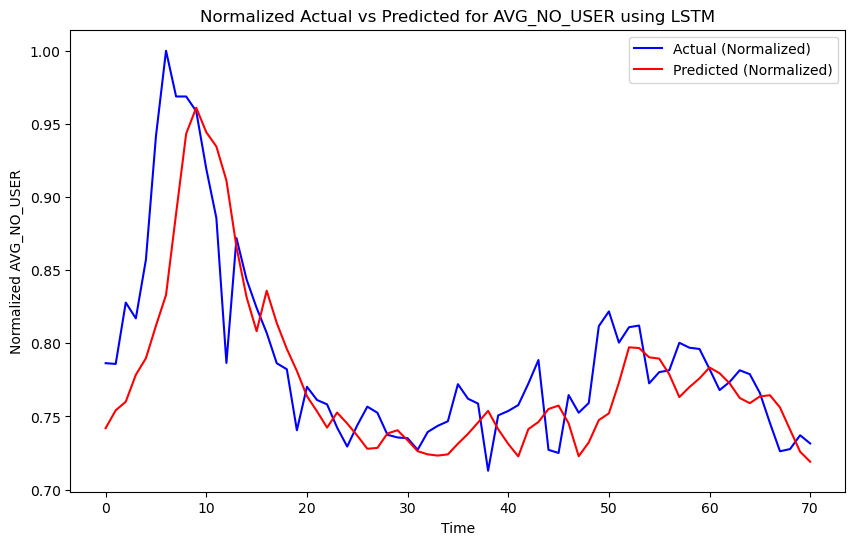

LSTM Model Metrics:
LSTM Model MSE (Normalized): 0.0016798264921385829
MAE: 0.02846179524132793
MAPE: 7.335791165530492%
RMSE: 0.040985686430003616
R-squared: 0.5767595144655678
MASE: 2.5431334512956107


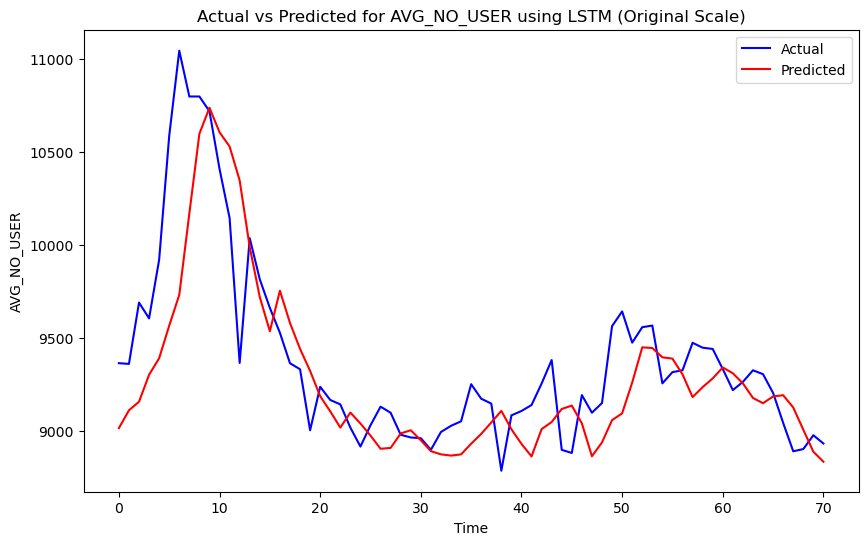

In [31]:
# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_lstm(train, look_back=look_back)
X_test, y_test = create_dataset_lstm(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()
# Calculate evaluation metrics
lstm_mae = mean_absolute_error(y_test, test_predict_lstm)
lstm_mape = np.mean(np.abs((y_test - test_predict_lstm) / y_test)) * 100  # MAPE in percentage
lstm_rmse = np.sqrt(mean_squared_error(y_test, test_predict_lstm))  # RMSE
lstm_r2 = r2_score(y_test, test_predict_lstm)  # R-squared

# MASE Calculation Function
def calculate_mase(y_true, y_pred, y_train):
    # Calculate the mean absolute error of the naive forecast (previous time step)
    naive_forecast = y_train[:-1]
    naive_errors = np.abs(y_train[1:] - naive_forecast)
    q = np.mean(naive_errors)
    
    # Calculate the mean absolute error of the predictions
    mae = np.mean(np.abs(y_true - y_pred))
    
    # MASE calculation
    mase = mae / q
    
    return mase

# Calculate MASE
lstm_mase = calculate_mase(y_test, test_predict_lstm, y_train)

# Print all evaluation metrics
print(f'LSTM Model Metrics:')
print(f'LSTM Model MSE (Normalized): {lstm_mse}')
print(f'MAE: {lstm_mae}')
print(f'MAPE: {lstm_mape}%')
print(f'RMSE: {lstm_rmse}')
print(f'R-squared: {lstm_r2}')
print(f'MASE: {lstm_mase}')

# Optional: Inverse transform predictions for original scale visualization
# Uncomment if you want to see predictions in original data scale
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
test_predict_lstm_original = scaler.inverse_transform(test_predict_lstm)

plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='Actual', color='blue')
plt.plot(test_predict_lstm_original, label='Predicted', color='red')
plt.title(f'Actual vs Predicted for {feature} using LSTM (Original Scale)')
plt.xlabel('Time')
plt.ylabel(feature)
plt.legend()
plt.show()

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Enhanced Dataset Creation Function
def create_enhanced_dataset(dataset, look_back=1, forecast_horizon=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back - forecast_horizon + 1):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back + forecast_horizon - 1, 0])
    return np.array(X), np.array(Y)

# Advanced MASE Calculation
def calculate_advanced_mase(y_true, y_pred, y_train):
    # Multiple naive forecast strategies
    naive_simple = y_train[:-1]
    moving_avg = np.convolve(y_train, np.ones(3)/3, 'valid')
    
    # Calculate errors for different naive methods
    simple_errors = np.abs(y_train[1:] - naive_simple)
    moving_avg_errors = np.abs(y_train[1:len(moving_avg)+1] - moving_avg)
    
    # Combine error metrics
    q_simple = np.mean(simple_errors)
    q_moving_avg = np.mean(moving_avg_errors)
    
    # Calculate MAE
    mae = np.mean(np.abs(y_true - y_pred))
    
    # Weighted MASE
    mase_simple = mae / (q_simple + 1e-10)
    mase_moving_avg = mae / (q_moving_avg + 1e-10)
    
    return min(mase_simple, mase_moving_avg)

# Advanced LSTM Model
def build_advanced_lstm_model(input_shape):
    model = Sequential([
        # First LSTM Layer with Batch Normalization
        LSTM(128, return_sequences=True, input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),
        
        # Second LSTM Layer
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),
        
        # Additional Dense Layers for Complex Feature Extraction
        Dense(32, activation='relu'),
        Dropout(0.2),
        
        Dense(16, activation='relu'),
        
        # Output Layer
        Dense(1)
    ])
    
    # Advanced Optimization
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    return model

# Comprehensive Training Function
def train_advanced_lstm(data, feature='AVG_NO_USER'):
    # Preprocessing
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data[[feature]])
    
    # Split Data
    train_size = int(len(scaled_data) * 0.8)
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Hyperparameter Tuning
    look_back_options = [3, 5, 7]
    best_r2 = -float('inf')
    best_config = {}
    
    for look_back in look_back_options:
        # Create Datasets
        X_train, y_train = create_enhanced_dataset(train, look_back=look_back)
        X_test, y_test = create_enhanced_dataset(test, look_back=look_back)
        
        # Reshape for LSTM
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
        
        # Callbacks
        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=15, 
            restore_best_weights=True
        )
        
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=7, 
            min_lr=0.00001
        )
        
        # Model Training
        lstm_model = build_advanced_lstm_model((look_back, 1))
        history = lstm_model.fit(
            X_train, y_train, 
            epochs=100, 
            batch_size=32, 
            validation_split=0.2, 
            callbacks=[early_stopping, reduce_lr],
            verbose=0
        )
        
        # Predictions
        test_predict_lstm = lstm_model.predict(X_test)
        
        # R-squared Calculation
        current_r2 = r2_score(y_test, test_predict_lstm)
        current_mase = calculate_advanced_mase(y_test, test_predict_lstm, y_train)
        
        # Update Best Configuration
        if current_r2 > best_r2:
            best_r2 = current_r2
            best_config = {
                'look_back': look_back,
                'r2_score': current_r2,
                'mase': current_mase,
                'model': lstm_model
            }
    
    # Print Best Configuration
    print("Best Configuration:")
    print(f"Look Back: {best_config['look_back']}")
    print(f"R-squared: {best_config['r2_score']}")
    print(f"MASE: {best_config['mase']}")
    
    return best_config



3/3 [==============================] - 1s 5ms/step
Best Configuration:
Look Back: 3
R-squared: -4.112371163334856
MASE: 6.525652046273961
3/3 [==============================] - 0s 3ms/step

Evaluation Metrics for the Best LSTM Model:
Mean Squared Error (MSE): 1250027.1734139249
Mean Absolute Error (MAE): 1045.3717765184858
Mean Absolute Percentage Error (MAPE): 11.229848754591512%
Root Mean Squared Error (RMSE): 1118.046141003995
R-squared: -4.11237175272799
Mean Absolute Scaled Error (MASE): 5.681956241675876


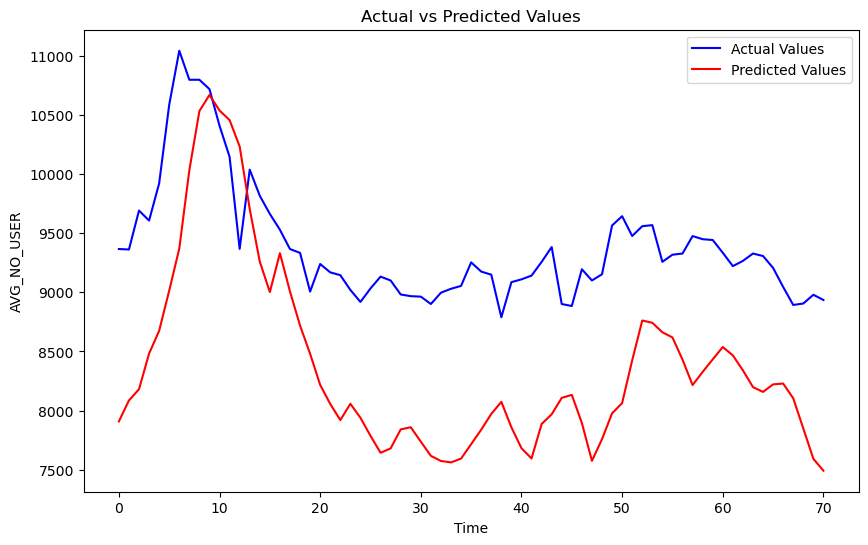

In [33]:
# Run the advanced training
best_lstm_config = train_advanced_lstm(data)

# Extract the best model and look_back from the configuration
best_model = best_lstm_config['model']
look_back = best_lstm_config['look_back']

# Preprocess the test data using the best look-back
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[['AVG_NO_USER']])
train_size = int(len(scaled_data) * 0.8)
test_data = scaled_data[train_size:]

X_test, y_test = create_enhanced_dataset(test_data, look_back=look_back)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Make predictions
test_predictions = best_model.predict(X_test)

# Rescale to original values
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
test_predictions_original = scaler.inverse_transform(test_predictions)

# Calculate Evaluation Metrics
mse = mean_squared_error(y_test_original, test_predictions_original)
mae = mean_absolute_error(y_test_original, test_predictions_original)
mape = np.mean(np.abs((y_test_original - test_predictions_original) / y_test_original)) * 100
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, test_predictions_original)
mase = calculate_advanced_mase(
    y_test_original.flatten(), 
    test_predictions_original.flatten(), 
    scaler.inverse_transform(scaled_data[:train_size].reshape(-1, 1)).flatten()
)

# Print Metrics
print("\nEvaluation Metrics for the Best LSTM Model:")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared: {r2}")
print(f"Mean Absolute Scaled Error (MASE): {mase}")

# Optional: Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='Actual Values', color='blue')
plt.plot(test_predictions_original, label='Predicted Values', color='red')
plt.title("Actual vs Predicted Values")
plt.xlabel("Time")
plt.ylabel("AVG_NO_USER")
plt.legend()
plt.show()

In [34]:
from tensorflow.keras.layers import Bidirectional
from sklearn.preprocessing import StandardScaler

In [35]:
def build_improved_lstm_model(input_shape):
    model = Sequential([
        # First Bidirectional LSTM Layer
        Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),

        # Second LSTM Layer
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),

        # Fully Connected Layers
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),

        # Output Layer
        Dense(1)
    ])
    
    # Optimizer with learning rate decay
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_absolute_error')
    
    return model

# Retraining Function
def retrain_lstm(data, feature='AVG_NO_USER'):
    # Preprocessing
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data[[feature]])
    
    # Train-Test Split
    train_size = int(len(scaled_data) * 0.8)
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Experimenting with Look-Back Window
    look_back = 5
    X_train, y_train = create_enhanced_dataset(train, look_back=look_back)
    X_test, y_test = create_enhanced_dataset(test, look_back=look_back)
    
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
    
    # Model Training
    model = build_improved_lstm_model((look_back, 1))
    model.fit(
        X_train, y_train,
        epochs=200,
        batch_size=16,
        validation_split=0.2,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    # Evaluate
    predictions = model.predict(X_test)
    y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
    predictions_original = scaler.inverse_transform(predictions)
    
    # Metrics
    mse = mean_squared_error(y_test_original, predictions_original)
    mae = mean_absolute_error(y_test_original, predictions_original)
    mape = np.mean(np.abs((y_test_original - predictions_original) / y_test_original)) * 100
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_original, predictions_original)
    mase = calculate_advanced_mase(
        y_test_original.flatten(),
        predictions_original.flatten(),
        scaler.inverse_transform(train.reshape(-1, 1)).flatten()
    )
    
    # Print Metrics
    print("\nImproved Model Metrics:")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R-squared: {r2}")
    print(f"Mean Absolute Scaled Error (MASE): {mase}")
    
    return model

# Retrain with enhanced configurations
improved_model = retrain_lstm(data)

Epoch 1/200
15/15 [==============================] - 13s 117ms/step - loss: 0.7349 - val_loss: 0.6750 - lr: 0.0010
Epoch 2/200
15/15 [==============================] - 0s 12ms/step - loss: 0.5713 - val_loss: 0.6789 - lr: 0.0010
Epoch 3/200
15/15 [==============================] - 0s 12ms/step - loss: 0.5162 - val_loss: 0.6598 - lr: 0.0010
Epoch 4/200
15/15 [==============================] - 0s 12ms/step - loss: 0.4843 - val_loss: 0.6189 - lr: 0.0010
Epoch 5/200
15/15 [==============================] - 0s 12ms/step - loss: 0.4057 - val_loss: 0.6282 - lr: 0.0010
Epoch 6/200
15/15 [==============================] - 0s 12ms/step - loss: 0.3984 - val_loss: 0.6171 - lr: 0.0010
Epoch 7/200
15/15 [==============================] - 0s 13ms/step - loss: 0.4316 - val_loss: 0.6386 - lr: 0.0010
Epoch 8/200
15/15 [==============================] - 0s 15ms/step - loss: 0.3515 - val_loss: 0.5821 - lr: 0.0010
Epoch 9/200
15/15 [==============================] - 0s 13ms/step - loss: 0.3940 - val_loss: 0

Epoch 71/200
15/15 [==============================] - 0s 25ms/step - loss: 0.2922 - val_loss: 0.1757 - lr: 1.0000e-05
Epoch 72/200
15/15 [==============================] - 0s 27ms/step - loss: 0.2914 - val_loss: 0.1756 - lr: 1.0000e-05
Epoch 73/200
15/15 [==============================] - 0s 27ms/step - loss: 0.2848 - val_loss: 0.1763 - lr: 1.0000e-05
Epoch 74/200
15/15 [==============================] - 0s 26ms/step - loss: 0.2930 - val_loss: 0.1760 - lr: 1.0000e-05
Epoch 75/200
15/15 [==============================] - 0s 26ms/step - loss: 0.2980 - val_loss: 0.1761 - lr: 1.0000e-05
Epoch 76/200
15/15 [==============================] - 0s 24ms/step - loss: 0.2646 - val_loss: 0.1763 - lr: 1.0000e-05
Epoch 77/200
15/15 [==============================] - 0s 16ms/step - loss: 0.2920 - val_loss: 0.1766 - lr: 1.0000e-05
Epoch 78/200
15/15 [==============================] - 0s 18ms/step - loss: 0.2966 - val_loss: 0.1766 - lr: 1.0000e-05
Epoch 79/200
3/3 [==============================] - 3s 8

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Normalize the dataset using Max Value normalization
def normalize_data(data, feature):
    max_value = data[feature].max()
    normalized_data = data[feature] / max_value
    return normalized_data, max_value

# Enhanced Dataset Creation Function
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back)])
        Y.append(dataset[i + look_back])
    return np.array(X), np.array(Y)

# Build an LSTM model with Bidirectional LSTM and enhancements
def build_lstm_model(input_shape):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True, input_shape=input_shape)),
        BatchNormalization(),
        Dropout(0.3),
        
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Main function to normalize data, train the model, and evaluate
def train_and_evaluate(data, feature='AVG_NO_USER'):
    # Normalize the data
    normalized_data, max_value = normalize_data(data, feature)
    normalized_data = normalized_data.values.reshape(-1, 1)
    
    # Split the data into train and test sets
    train_size = int(len(normalized_data) * 0.8)
    train, test = normalized_data[:train_size], normalized_data[train_size:]
    
    # Create the dataset for the LSTM model
    look_back = 5  # Adjust as needed
    X_train, y_train = create_dataset(train, look_back)
    X_test, y_test = create_dataset(test, look_back)
    
    # Reshape input for LSTM: [samples, timesteps, features]
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Initialize and train the model
    model = build_lstm_model((look_back, 1))
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
    
    model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=16,
        validation_split=0.2,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    # Make predictions
    train_predict = model.predict(X_train)
    test_predict = model.predict(X_test)
    
    # Denormalize the predictions and actual values
    y_train_original = y_train * max_value
    y_test_original = y_test * max_value
    train_predict_original = train_predict * max_value
    test_predict_original = test_predict * max_value
    
    # Evaluate the model
    mse = mean_squared_error(y_test_original, test_predict_original)
    mae = mean_absolute_error(y_test_original, test_predict_original)
    mape = np.mean(np.abs((y_test_original - test_predict_original) / y_test_original)) * 100
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_original, test_predict_original)
    
    # Print the evaluation metrics
    print("\nModel Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R-squared: {r2}")
    
    # Plot the actual vs predicted values
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Actual Values", color='blue')
    plt.plot(test_predict_original, label="Predicted Values", color='red')
    plt.title(f"Actual vs Predicted for {feature} (Denormalized)")
    plt.xlabel("Time")
    plt.ylabel(f"{feature}")
    plt.legend()
    plt.show()



In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Normalize the dataset using Max Value normalization
def normalize_data(data, feature):
    max_value = data[feature].max()
    normalized_data = data[feature] / max_value
    return normalized_data, max_value

# Enhanced Dataset Creation Function
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back)])
        Y.append(dataset[i + look_back])
    return np.array(X), np.array(Y)

# Build the LSTM model
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Calculate Mean Absolute Scaled Error (MASE)
def calculate_mase(y_true, y_pred, y_train):
    naive_forecast = y_train[:-1]
    naive_errors = np.abs(y_train[1:] - naive_forecast)
    q = np.mean(naive_errors)
    mae = np.mean(np.abs(y_true - y_pred))
    mase = mae / (q + 1e-10)
    return mase

# Train and evaluate the model with normalized data
def train_and_evaluate(data, feature='AVG_NO_USER'):
    # Normalize the data
    normalized_data, max_value = normalize_data(data, feature)
    normalized_data = normalized_data.values.reshape(-1, 1)
    
    # Split data into train and test sets
    train_size = int(len(normalized_data) * 0.8)
    train, test = normalized_data[:train_size], normalized_data[train_size:]
    
    # Create datasets for LSTM
    look_back = 5  # Look-back period
    X_train, y_train = create_dataset(train, look_back)
    X_test, y_test = create_dataset(test, look_back)
    
    # Reshape input for LSTM
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Train the LSTM model
    model = build_lstm_model((look_back, 1))
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
    
    model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=16,
        validation_split=0.2,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    # Make predictions
    train_predict = model.predict(X_train)
    test_predict = model.predict(X_test)
    
    # Denormalize predictions and actual values
    y_train_original = y_train * max_value
    y_test_original = y_test * max_value
    train_predict_original = train_predict * max_value
    test_predict_original = test_predict * max_value
    
    # Compute evaluation metrics
    mse = mean_squared_error(y_test_original, test_predict_original)
    mae = mean_absolute_error(y_test_original, test_predict_original)
    mape = np.mean(np.abs((y_test_original - test_predict_original) / y_test_original)) * 100
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_original, test_predict_original)
    mase = calculate_mase(y_test, test_predict, y_train)
    
    # Print evaluation metrics
    print("\nEvaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R-squared: {r2}")
    print(f"Mean Absolute Scaled Error (MASE): {mase}")
    
    # Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Actual Values", color='blue')
    plt.plot(test_predict_original, label="Predicted Values", color='red')
    plt.title(f"Actual vs Predicted for {feature} (Denormalized)")
    plt.xlabel("Time")
    plt.ylabel(f"{feature}")
    plt.legend()
    plt.show()

# Example usage with your dataset
# Replace `data` with your DataFrame
# train_and_evaluate(data, feature='AVG_NO_USER')


In [38]:
    # Print evaluation metrics
    print("\nEvaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R-squared: {r2}")
    print(f"Mean Absolute Scaled Error (MASE): {mase}")


Evaluation Metrics:
Mean Squared Error (MSE): 1250027.1734139249
Mean Absolute Error (MAE): 1045.3717765184858
Mean Absolute Percentage Error (MAPE): 11.229848754591512%
Root Mean Squared Error (RMSE): 1118.046141003995
R-squared: -4.11237175272799
Mean Absolute Scaled Error (MASE): 5.681956241675876


NameError: name 'test_predict_original' is not defined

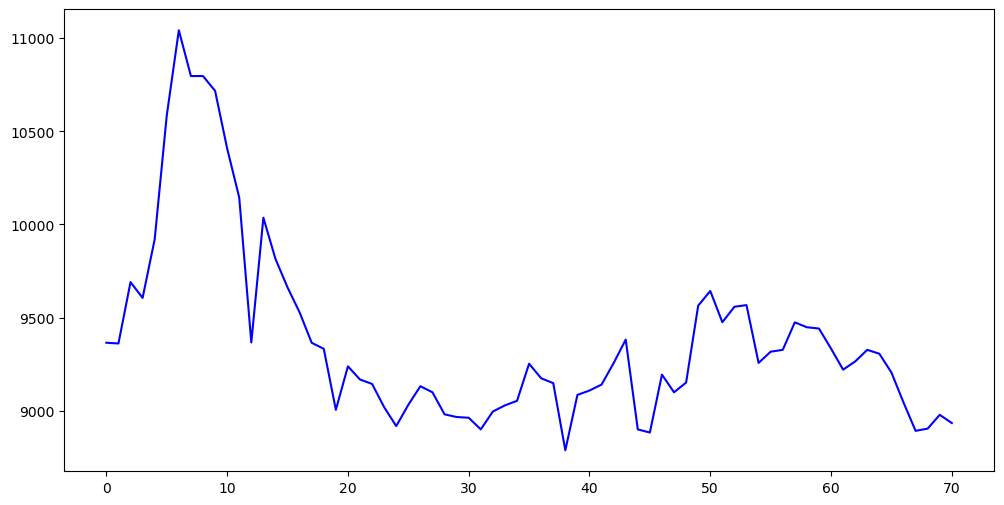

In [39]:
    # Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Actual Values", color='blue')
    plt.plot(test_predict_original, label="Predicted Values", color='red')
    plt.title(f"Actual vs Predicted for {feature} (Denormalized)")
    plt.xlabel("Time")
    plt.ylabel(f"{feature}")
    plt.legend()
    plt.show()

In [ ]:
# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_lstm(train, look_back=look_back)
X_test, y_test = create_dataset_lstm(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [ ]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area3.csv')

# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_lstm(train, look_back=look_back)
X_test, y_test = create_dataset_lstm(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(150, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.3))
    model.add(LSTM(100, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [ ]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area2.csv')

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Fit the ARIMA model
# (p, d, q) are ARIMA parameters. Start with simple values like (p=5, d=1, q=0)
model = ARIMA(train, order=(5, 1, 0))  # You can experiment with these values
arima_model = model.fit()

# Make predictions on test data
test_predict_arima = arima_model.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import matplotlib.pyplot as plt

In [ ]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area4.csv')


In [ ]:
data

In [ ]:

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'

# Normalize the 'AVG_USR_THRPUT_DL' data
#scaler = MinMaxScaler(feature_range=(0, 1))
#scaled_data = scaler.fit_transform(data[[feature]])

# Initialize the MaxAbsScaler
scaler = MaxAbsScaler()

# Normalize the 'Traffic' data
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Fit the ARIMA model
# (p, d, q) are ARIMA parameters. Start with simple values like (p=5, d=1, q=0)
model = ARIMA(train, order=(5, 1, 0))  # You can experiment with these values
arima_model = model.fit()

# Make predictions on test data
test_predict_arima = arima_model.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [ ]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area4.csv')

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'AVG_USR_THRPUT_DL' data
#scaler = MinMaxScaler(feature_range=(0, 1))
#scaled_data = scaler.fit_transform(data[[feature]])

# Initialize the MaxAbsScaler
scaler = MaxAbsScaler()

# Normalize the 'Traffic' data
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Fit the ARIMA model
# (p, d, q) are ARIMA parameters. Start with simple values like (p=5, d=1, q=0)
model = ARIMA(train, order=(5, 1, 0))  # You can experiment with these values
arima_model = model.fit()

# Make predictions on test data
test_predict_arima = arima_model.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [ ]:
# Load your dataset
#data = pd.read_csv('../../data/Area3.csv')

# Prepare data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'

# Normalize the 'AVG_USR_THRPUT_DL' data
#scaler = MinMaxScaler(feature_range=(0, 1))
#scaled_data = scaler.fit_transform(data[[feature]])

# Initialize the MaxAbsScaler
scaler = MaxAbsScaler()

# Normalize the 'Traffic' data
scaled_data = scaler.fit_transform(data[[feature]])


# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Find the best ARIMA parameters
stepwise_model = auto_arima(train, start_p=1, start_q=1,
                            max_p=6, max_q=6, m=1,
                            start_P=0, seasonal=False,
                            d=1, trace=True,
                            error_action='ignore',  
                            suppress_warnings=True, 
                            stepwise=True)

# Fit the ARIMA model with the optimal parameters
arima_model = ARIMA(train, order=stepwise_model.order)
arima_model_fit = arima_model.fit()

# Make predictions on test data
test_predict_arima = arima_model_fit.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'Optimized ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using Optimized ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [ ]:
# Load your dataset
data = pd.read_csv('../../data/Area3.csv')

In [ ]:
# Try SARIMA model with seasonal adjustment
stepwise_model_seasonal = auto_arima(train, start_p=1, start_q=1,
                                     max_p=6, max_q=6, m=12,  # Set m to your data's seasonal frequency
                                     start_P=0, seasonal=True,
                                     d=1, D=1, trace=True,
                                     error_action='ignore',  
                                     suppress_warnings=True, 
                                     stepwise=True)

# Fit the SARIMA model with the optimal parameters
sarima_model = ARIMA(train, order=stepwise_model_seasonal.order, seasonal_order=stepwise_model_seasonal.seasonal_order)
sarima_model_fit = sarima_model.fit()

# Forecast with SARIMA model
test_predict_sarima = sarima_model_fit.forecast(steps=len(test))

# Calculate MSE for SARIMA model
sarima_mse = mean_squared_error(test, test_predict_sarima)
print(f'Optimized SARIMA Model MSE (Normalized): {sarima_mse}')

# Plot the SARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_sarima, label='Predicted (Normalized)', color='green')
plt.title(f'Normalized Actual vs Predicted for {feature} using Optimized SARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import matplotlib.pyplot as plt

In [ ]:

# Load your dataset (adjust the path to where your file is located)
#data = pd.read_csv('../../data/Area2.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# No need to invert the values; everything stays normalized

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()

In [ ]:

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area2.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_USR_THRPUT_DL'
feature = 'AVG_USR_THRPUT_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# No need to invert the values; everything stays normalized

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel(f'{feature} (Normalized)')
plt.legend()
plt.show()

In [ ]:

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area1.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Traffic'
feature = 'DL_TRAFFIC_MB'

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])


# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# No need to invert the values; everything stays normalized

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel(f'{feature} (Normalized)')
plt.legend()
plt.show()

In [ ]:
data

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D,GRU, Dense, Flatten, Dropout

In [ ]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [ ]:
# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for CNN-GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for CNN-GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for CNN and GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define the CNN-GRU model
def build_cnn_gru_model(input_shape):
    model = Sequential()
    
    # 1D CNN layers
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    
    # GRU layers
    model.add(GRU(100, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    
    # Dense output layer
    model.add(Dense(1))
    
    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train CNN-GRU model
cnn_gru_model = build_cnn_gru_model((look_back, 2))
cnn_gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the CNN-GRU model
train_predict_gru = cnn_gru_model.predict(X_train_gru)
test_predict_gru = cnn_gru_model.predict(X_test_gru)

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Hybrid CNN-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()

In [ ]:
# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for CNN-LSTM model
def create_dataset_lstm(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for CNN-LSTM
X_train_lstm, y_train_lstm = create_dataset_lstm(train_predict_svm, train, look_back=look_back)
X_test_lstm, y_test_lstm = create_dataset_lstm(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for CNN and LSTM input
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 2))  # Two features: original and SVM
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 2))

# Define the CNN-LSTM model
def build_cnn_lstm_model(input_shape):
    model = Sequential()
    
    # 1D CNN layers
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    
    # LSTM layers
    model.add(LSTM(100, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    
    # Dense output layer
    model.add(Dense(1))
    
    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train CNN-LSTM model
cnn_lstm_model = build_cnn_lstm_model((look_back, 2))
cnn_lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the CNN-LSTM model
train_predict_lstm = cnn_lstm_model.predict(X_train_lstm)
test_predict_lstm = cnn_lstm_model.predict(X_test_lstm)

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_lstm, test_predict_lstm)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Hybrid CNN-LSTM Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, concatenate
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, concatenate, Flatten
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Define the input shape
input_shape = (look_back, 2)  # look_back timesteps, 2 features (SVM and original)

# Define input layer
input_layer = Input(shape=input_shape)

# CNN Path
cnn = Conv1D(filters=64, kernel_size=2, activation='relu')(input_layer)
cnn = MaxPooling1D(pool_size=2)(cnn)
cnn = Dropout(0.2)(cnn)
cnn = Flatten()(cnn)  # Flatten CNN output to 2D

# LSTM Path
lstm = LSTM(100, return_sequences=False)(input_layer)
lstm = Dropout(0.2)(lstm)

# Merge the outputs of both paths
merged = concatenate([cnn, lstm])

# Fully connected layer
dense = Dense(50, activation='relu')(merged)
output = Dense(1)(dense)

# Build and compile the model
parallel_model = Model(inputs=input_layer, outputs=output)
parallel_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
parallel_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the parallel CNN-LSTM model
train_predict_parallel = parallel_model.predict(X_train_gru)
test_predict_parallel = parallel_model.predict(X_test_gru)

# Calculate normalized MSE
normalized_mse_parallel = mean_squared_error(y_test_gru, test_predict_parallel)
print(f'Normalized MSE: {normalized_mse_parallel}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_parallel, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Parallel CNN-LSTM Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()

In [ ]:
# Load your dataset (adjust the path to where your file is located)
#data = pd.read_csv('../../data/Site3data.csv')